# InfoGAN

Original paper: [InfoGAN: Interpretable Representation Learning by Information Maximizing Generative Adversarial Nets](https://arxiv.org/abs/1606.03657)

In [1]:
import os
import matplotlib.pyplot as plt
import torch
import torchvision
import numpy as np
from torch import nn
import torchvision.transforms as T
from torch.nn import functional as F
from torchvision.utils import make_grid

In [2]:
transform = T.Compose([
    T.ToTensor(),
    T.Normalize((0.5,),(0.5,))
    ])

train_data = torchvision.datasets.MNIST(root="data/mnist", train=True, download=True,
                                        transform=transform)

In [3]:
train_batch_size = 128
num_workers = 2
train_dataloader = torch.utils.data.DataLoader(dataset=train_data, batch_size=train_batch_size, num_workers=num_workers, shuffle=True)

In [4]:
def show_batch(batch, figsize=(10,8), num_images=None, save_name=None):
    images, labels = batch
    num_images = num_images if num_images is not None else len(images)
    nrows = int(np.sqrt(num_images))
    ncols = int(np.ceil(num_images / nrows))
    fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=figsize)
    axes = axes.ravel()
    for ax in axes: ax.axis("off")
    for i in range(num_images):
        axes[i].imshow(images[i][0], cmap="gray")
        # axes[i].set_title(f"{labels[i]}")
    if save_name is not None: plt.savefig(save_name)
    plt.show()


torch.Size([128, 1, 28, 28])


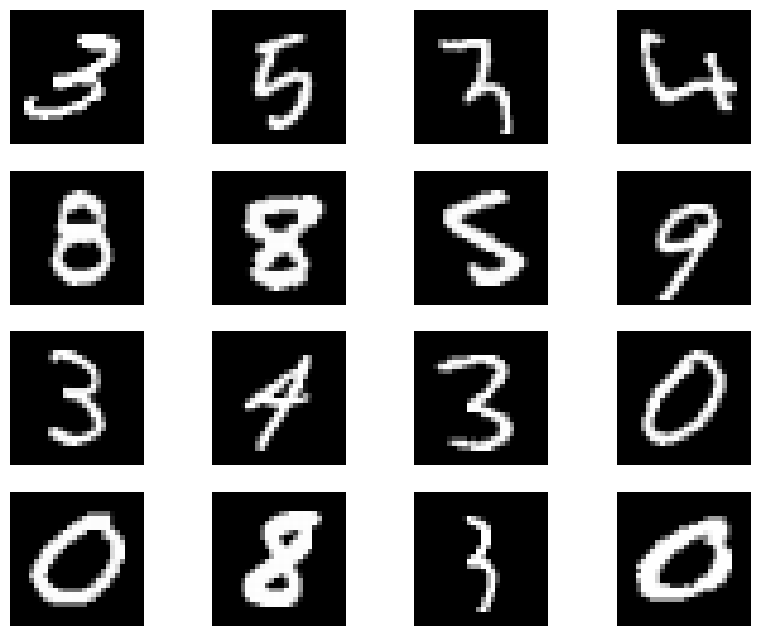

In [5]:
for batch in train_dataloader:
    print(batch[0].shape)
    show_batch(batch, num_images=16,)
    break

In [6]:
class Generator(nn.Module):
    def __init__(self, init_channels: int = 1024, latent_dim: int = 62, img_channels: int = 1, num_classes: int = 10, num_codes: int = 2):
        super(Generator, self).__init__()
        self.num_classes = num_classes
        self.num_codes = num_codes
        
        self.lin_z = nn.Linear(in_features=latent_dim, out_features=latent_dim)
        self.lin_c1 = nn.Linear(in_features=num_classes, out_features=num_classes)
        self.lin_c2 = nn.Linear(in_features=num_codes, out_features=num_codes)

        self.fc1 = nn.Sequential(
            nn.Linear(in_features=latent_dim+num_classes+num_codes, out_features=init_channels),
            nn.ReLU(), nn.BatchNorm1d(init_channels)
        )
        self.fc2 = nn.Sequential(
            nn.Linear(in_features=init_channels, out_features=128*7*7),
            nn.ReLU(), nn.BatchNorm1d(128*7*7)
        )
        self.conv = nn.Sequential(
            nn.ConvTranspose2d(in_channels=128, out_channels=64, kernel_size=4, stride=2, padding=1),
            nn.ReLU(), nn.BatchNorm2d(64), # output shape: (64, 14, 14)
            nn.ConvTranspose2d(in_channels=64, out_channels=img_channels, stride=2, kernel_size=4, padding=1),
            nn.Tanh() # output shape: (64, 28, 28)
        )

    def forward(self, z, c1, c2):
        lz  = F.relu(self.lin_z(z))
        lc1 = F.relu(self.lin_c1(c1))
        lc2 = F.relu(self.lin_c2(c2))
        out = torch.cat((lz,lc1,lc2), dim=1)
        out = self.fc1(out)
        out = self.fc2(out)
        out = out.view(-1, 128, 7, 7)
        out = self.conv(out)
        return out

In [7]:
latent_dim = 62
num_codes = 2
num_classes = 10

generator = Generator(init_channels=1024, latent_dim=latent_dim, num_classes=num_classes, num_codes=num_codes)
c1 = F.one_hot(torch.randint(0, 10, (train_batch_size,))).float()
c2 = 2. * torch.rand(train_batch_size, num_codes) - 1.
z = torch.normal(0., 1., size=(train_batch_size, latent_dim))
batch_out = generator(z, c1, c2)
print("In shapes:", z.shape, c1.shape, c2.shape)
print("Out shape:", batch_out.shape)
generator

In shapes: torch.Size([128, 62]) torch.Size([128, 10]) torch.Size([128, 2])
Out shape: torch.Size([128, 1, 28, 28])


Generator(
  (lin_z): Linear(in_features=62, out_features=62, bias=True)
  (lin_c1): Linear(in_features=10, out_features=10, bias=True)
  (lin_c2): Linear(in_features=2, out_features=2, bias=True)
  (fc1): Sequential(
    (0): Linear(in_features=74, out_features=1024, bias=True)
    (1): ReLU()
    (2): BatchNorm1d(1024, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  )
  (fc2): Sequential(
    (0): Linear(in_features=1024, out_features=6272, bias=True)
    (1): ReLU()
    (2): BatchNorm1d(6272, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  )
  (conv): Sequential(
    (0): ConvTranspose2d(128, 64, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (1): ReLU()
    (2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (3): ConvTranspose2d(64, 1, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (4): Tanh()
  )
)

In [8]:
class Discriminator(nn.Module):
    def __init__(self, init_channels: int = 64, img_channels: int = 1, num_classes:int = 10, num_codes: int = 2, alpha: float = 0.1):
        super(Discriminator, self).__init__()
        self.num_classes = num_classes
        self.conv = nn.Sequential(
            nn.Conv2d(in_channels=img_channels, out_channels=init_channels, kernel_size=4, stride=2, padding=1),
            nn.LeakyReLU(alpha), # output shape: (init_channels, 14, 14)
            nn.Conv2d(in_channels=init_channels, out_channels=init_channels*2, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm2d(init_channels*2),
            nn.LeakyReLU(alpha) # output shape: (init_channels*2, 7, 7)
        )
        self.fc_shared = nn.Sequential(
            nn.Linear(in_features=init_channels*2*7*7, out_features=1024),
            nn.BatchNorm1d(1024),
            nn.LeakyReLU(alpha),
        )
        self.head = nn.Linear(in_features=1024, out_features=1)
        self.q_net = nn.Sequential(
            nn.Linear(in_features=1024, out_features=128),
            nn.BatchNorm1d(128), 
            nn.LeakyReLU(alpha),
        )
        self.q_c1 = nn.Linear(128, num_classes)
        self.q_c2 = nn.Linear(128, num_codes)
      
        
    def forward(self, x):
        out = self.conv(x)
        features = out.view(x.size(0), -1)
        shared = self.fc_shared(features)
        d_out = self.head(shared)  # real or fake
        q = self.q_net(shared)
        c1 = self.q_c1(q)
        c2 = self.q_c2(q)
        return d_out, c1, c2

In [9]:
discriminator = Discriminator(init_channels=64, num_classes=num_classes, num_codes=num_codes, img_channels=1)
batch_in = torch.normal(0, 1, (train_batch_size, 1, 28, 28))
batch_out1, batch_out2, batch_out3 = discriminator(batch_in)
print("In shape:", batch_in.shape)
print("Out shapes:", batch_out1.shape, batch_out2.shape, batch_out3.shape)
discriminator

In shape: torch.Size([128, 1, 28, 28])
Out shapes: torch.Size([128, 1]) torch.Size([128, 10]) torch.Size([128, 2])


Discriminator(
  (conv): Sequential(
    (0): Conv2d(1, 64, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (1): LeakyReLU(negative_slope=0.1)
    (2): Conv2d(64, 128, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (3): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (4): LeakyReLU(negative_slope=0.1)
  )
  (fc_shared): Sequential(
    (0): Linear(in_features=6272, out_features=1024, bias=True)
    (1): BatchNorm1d(1024, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): LeakyReLU(negative_slope=0.1)
  )
  (head): Linear(in_features=1024, out_features=1, bias=True)
  (q_net): Sequential(
    (0): Linear(in_features=1024, out_features=128, bias=True)
    (1): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): LeakyReLU(negative_slope=0.1)
  )
  (q_c1): Linear(in_features=128, out_features=10, bias=True)
  (q_c2): Linear(in_features=128, out_features=2, bias=True)
)

In [10]:
def init_weights(w):
    if isinstance(w, (nn.Linear, nn.Conv2d, nn.ConvTranspose2d)):
        torch.nn.init.normal_(w.weight.data, 0., 0.02)
        if w.bias is not None:
            torch.nn.init.constant_(w.bias.data, 0.0)
    elif isinstance(w, (nn.BatchNorm2d, nn.BatchNorm1d)):
        torch.nn.init.normal_(w.weight.data, 1.0, 0.02)
        torch.nn.init.constant_(w.bias.data, 0.0)

In [11]:
def update_discriminator(x, z, c1, c2, D, G, criterion, trainer_D):
    trainer_D.zero_grad()
    batch_size = x.shape[0]
    zeros = torch.zeros((batch_size,), device=x.device)
    ones = torch.ones((batch_size,), device=x.device)
    real_y, _, _ = D(x)
    fake_x = G(z, c1, c2)
    # Do not need to compute gradient for G, detach it from computing gradients.
    fake_y, _, _ = D(fake_x.detach())
    loss_D = (criterion(real_y, ones.reshape(real_y.shape)) +
        criterion(fake_y, zeros.reshape(fake_y.shape))) / 2
    loss_D.backward()
    trainer_D.step()
    return loss_D.item()

def update_generator(z, c1, c2, D, G, criterion, trainer_GQ, lambd):
    trainer_GQ.zero_grad()
    batch_size = z.shape[0]
    ones = torch.ones((batch_size,), device=z.device)
    fake_x = G(z, c1, c2)
    fake_y, fake_c1, fake_c2 = D(fake_x)
    loss_G = criterion(fake_y, ones.reshape(fake_y.shape))

    loss_cat = nn.CrossEntropyLoss()(fake_c1, torch.argmax(c1, dim=1))
    loss_cont = lambd * nn.MSELoss()(fake_c2, c2)
    loss_info =  loss_cat + loss_cont
    loss_total = loss_G + loss_info
    loss_total.backward()
    trainer_GQ.step()
    return loss_G.item(), loss_info.item()

In [12]:
def train_infogan(D, G, lr_D, lr_G, latent_dim, dataloader, num_codes, num_epochs, device,
                  fixed_noise, fixed_label, fixed_code, lambd=1., visualize=True):
    print(f"Device: {device}")
    criterion = nn.BCEWithLogitsLoss()

    G = G.to(device)
    D = D.to(device)

    D.apply(init_weights)
    G.apply(init_weights)

    trainer_D = torch.optim.Adam([
        {"params": D.head.parameters()},
        {"params": D.fc_shared.parameters()},
        {"params": D.conv.parameters()}],
        lr=lr_D, betas=(0.5, 0.999))
    trainer_GQ = torch.optim.Adam([
        {"params": G.parameters()},
        {"params": D.q_net.parameters()},
        {"params": D.q_c1.parameters()},
        {"params": D.q_c2.parameters()}],
        lr=lr_G, betas=(0.5, 0.999))

    metrics = []

    fixed_noise = fixed_noise.to(device)
    fixed_label = fixed_label.to(device)
    fixed_code = fixed_code.to(device)

    for epoch in range(num_epochs):
        G.train()
        D.train()
        loss_D_epoch = 0.
        loss_G_epoch = 0.
        loss_info_epoch = 0.
        num_instances = 0
        for step_num, batch in enumerate(dataloader):
            x,_ = batch
            x = x.to(device)
            batch_size = x.shape[0]
            num_instances += batch_size


            # # update discriminator
            # trainer_D.zero_grad()
            # zeros = torch.zeros((batch_size,), device=device)
            # ones = torch.ones((batch_size,), device=device)
            # real_y, _, _ = D(x)
            # c1 = F.one_hot(torch.randint(0, 10, (batch_size,))).to(device).float()
            # c2 = 2. * torch.rand(batch_size, num_codes, device=device) - 1.
            # z = torch.normal(0., 1., size=(batch_size, latent_dim), device=device)
            # fake_x = G(z, c1, c2)
            # # Do not need to compute gradient for G, detach it from computing gradients.
            # fake_y, _, _ = D(fake_x.detach())
            # loss_D = (criterion(real_y, ones.reshape(real_y.shape)) +
            #     criterion(fake_y, zeros.reshape(fake_y.shape))) / 2
            # loss_D.backward()
            # trainer_D.step()
            # loss_D_epoch += loss_D.item() * batch_size
            

            # # update generator and information loss
            # trainer_GQ.zero_grad()
            # c1 = F.one_hot(torch.randint(0, 10, (batch_size,))).to(device).float()
            # c2 = 2. * torch.rand(batch_size, num_codes, device=device) - 1.
            # z = torch.normal(0., 1., size=(batch_size, latent_dim), device=device)
            # fake_x = G(z, c1, c2)
            # fake_y, fake_c1, fake_c2 = D(fake_x)
            # loss_G = criterion(fake_y, ones.reshape(fake_y.shape))

            # loss_cat = nn.CrossEntropyLoss()(fake_c1, torch.argmax(c1, dim=1))
            # loss_cont = lambd * nn.MSELoss()(fake_c2, c2)
            # loss_info =  loss_cat + loss_cont
            # loss_total = loss_G + loss_info
            # loss_total.backward()
            # trainer_GQ.step()
            # loss_G_epoch += loss_G.item() * batch_size
            # loss_info_epoch += loss_info.item() * batch_size

            c1 = F.one_hot(torch.randint(0, 10, (batch_size,))).to(device).float()
            c2 = 2. * torch.rand(batch_size, num_codes, device=device) - 1.
            z = torch.normal(0., 1., size=(batch_size, latent_dim), device=device)
            loss_D = update_discriminator(x=x, z=z, c1=c1, c2=c2, D=D, G=G, criterion=criterion, trainer_D=trainer_D)
            loss_G, loss_info = update_generator(z=z, c1=c1, c2=c2, D=D, G=G, criterion=criterion, trainer_GQ=trainer_GQ, lambd=lambd)

            loss_D_epoch += loss_D * batch_size
            loss_G_epoch += loss_G * batch_size
            loss_info_epoch += loss_info * batch_size

        loss_D_epoch /= num_instances
        loss_G_epoch /= num_instances
        loss_info_epoch /= num_instances
        metrics.append([loss_D_epoch, loss_G_epoch, loss_info_epoch])
        print(f"[Epoch {epoch}/{num_epochs}] loss_D: {loss_D_epoch:.4f}, loss_G: {loss_G_epoch:.4f}, loss_info: {loss_info_epoch:.4f}")

        G.eval()
        D.eval()
    
        if visualize:
            print("Generated images:")
            os.makedirs("visualizations", exist_ok=True)
            with torch.no_grad():
                fake_data = G(fixed_noise, fixed_label, fixed_code).detach().cpu()
                show_batch((fake_data,None), save_name=f"visualizations/generated-{epoch:02d}.png")

    metrics = np.array(metrics)
    plt.semilogy(metrics[:, 0], label="loss_D")
    plt.semilogy(metrics[:, 1], label="loss_G")
    plt.semilogy(metrics[:, 2], label="loss_info")
    plt.legend()
    plt.show()

In [13]:
!rm -rf visualizations

Device: cuda
[Epoch 0/50] loss_D: 0.5864, loss_G: 0.9900, loss_info: 0.2504
Generated images:


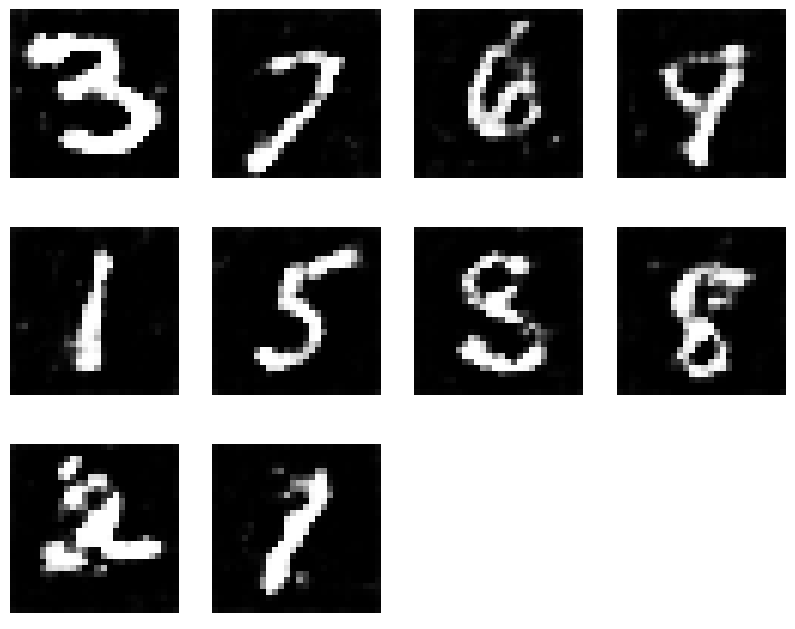

[Epoch 1/50] loss_D: 0.6005, loss_G: 0.9635, loss_info: 0.0536
Generated images:


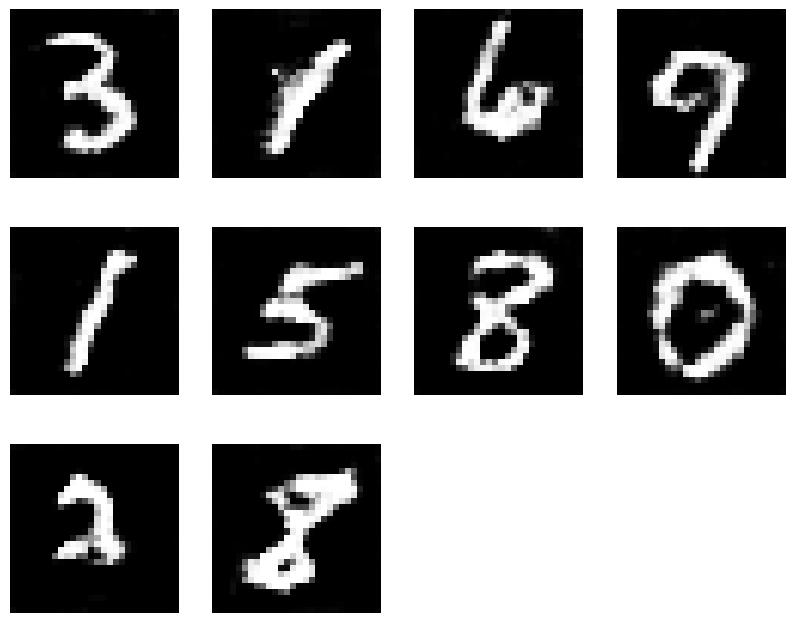

[Epoch 2/50] loss_D: 0.6057, loss_G: 0.9665, loss_info: 0.0467
Generated images:


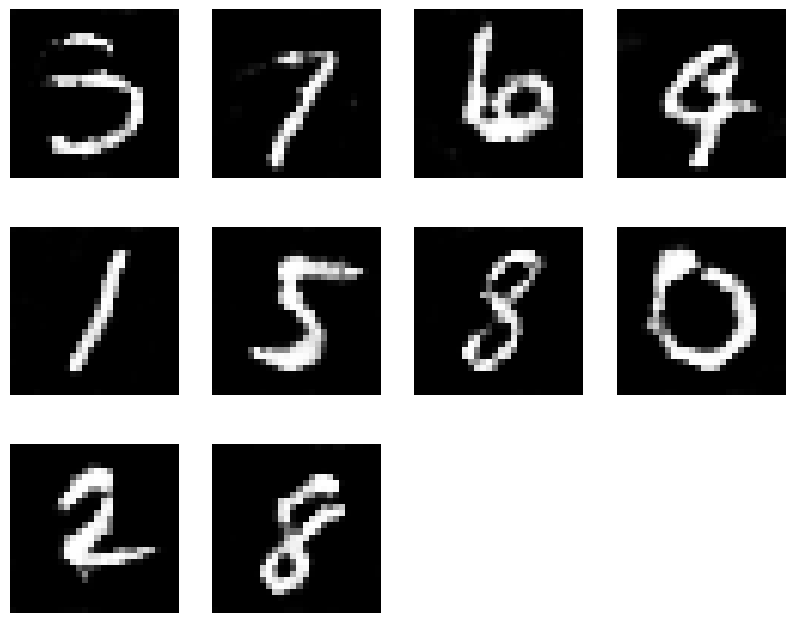

[Epoch 3/50] loss_D: 0.5978, loss_G: 0.9916, loss_info: 0.0449
Generated images:


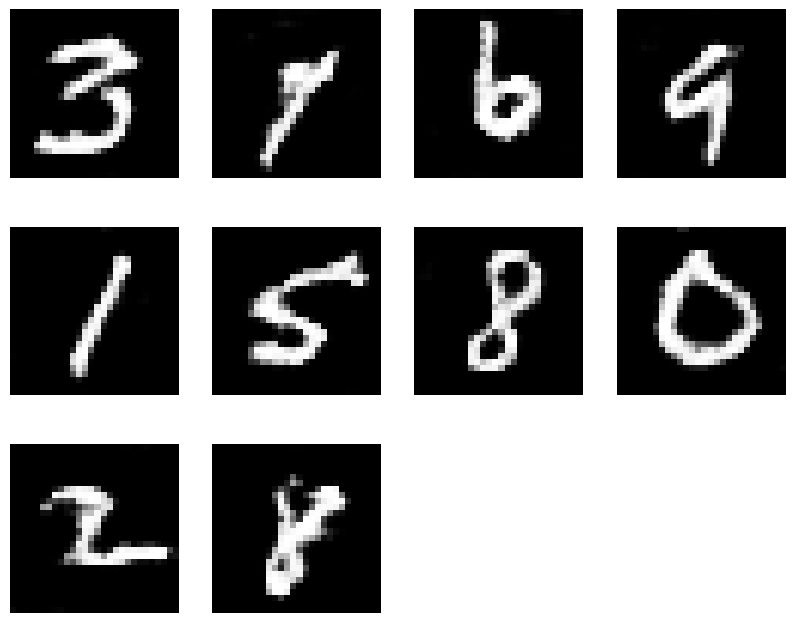

[Epoch 4/50] loss_D: 0.5871, loss_G: 1.0186, loss_info: 0.0448
Generated images:


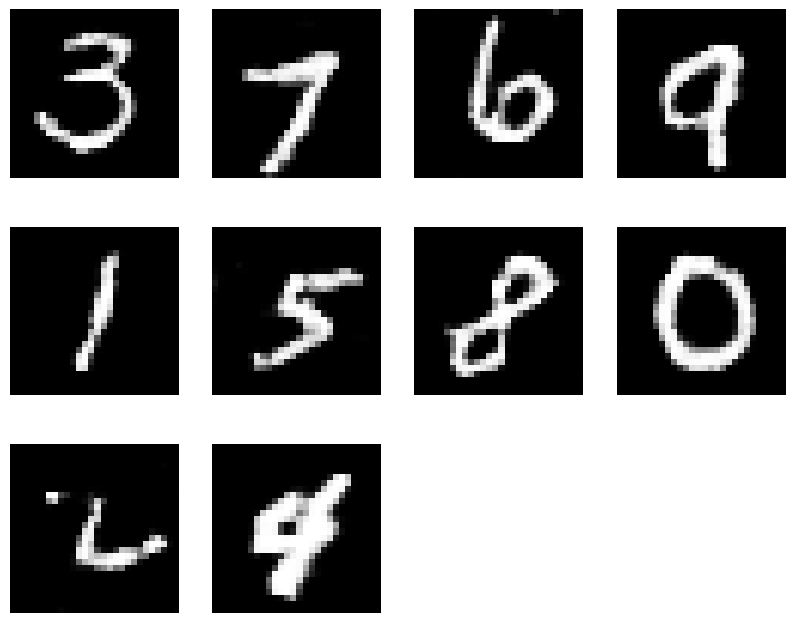

[Epoch 5/50] loss_D: 0.5777, loss_G: 1.0457, loss_info: 0.0451
Generated images:


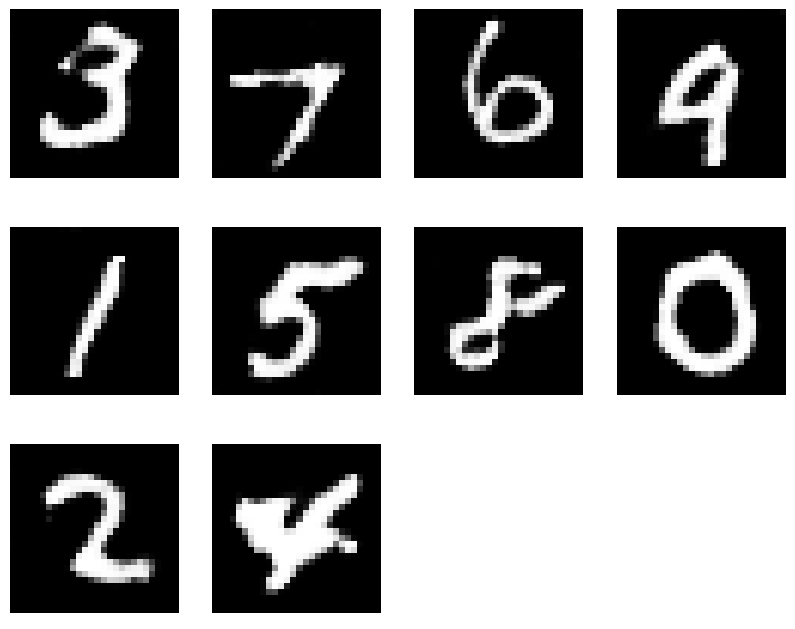

[Epoch 6/50] loss_D: 0.5639, loss_G: 1.0861, loss_info: 0.0459
Generated images:


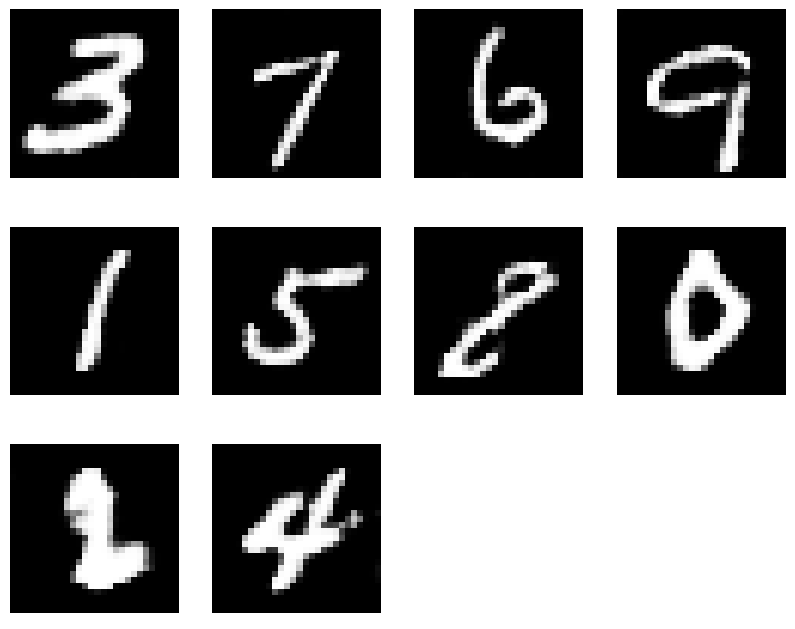

[Epoch 7/50] loss_D: 0.5501, loss_G: 1.1147, loss_info: 0.0465
Generated images:


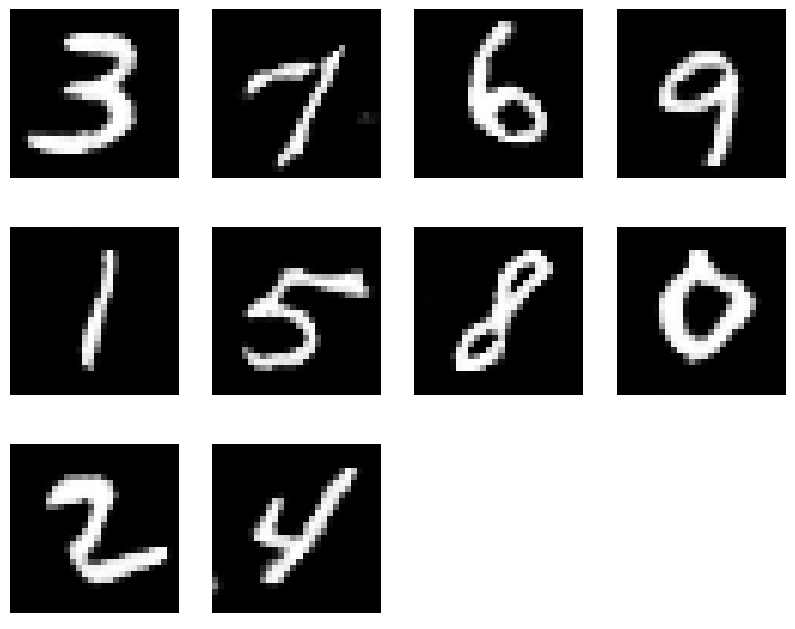

[Epoch 8/50] loss_D: 0.5346, loss_G: 1.1592, loss_info: 0.0473
Generated images:


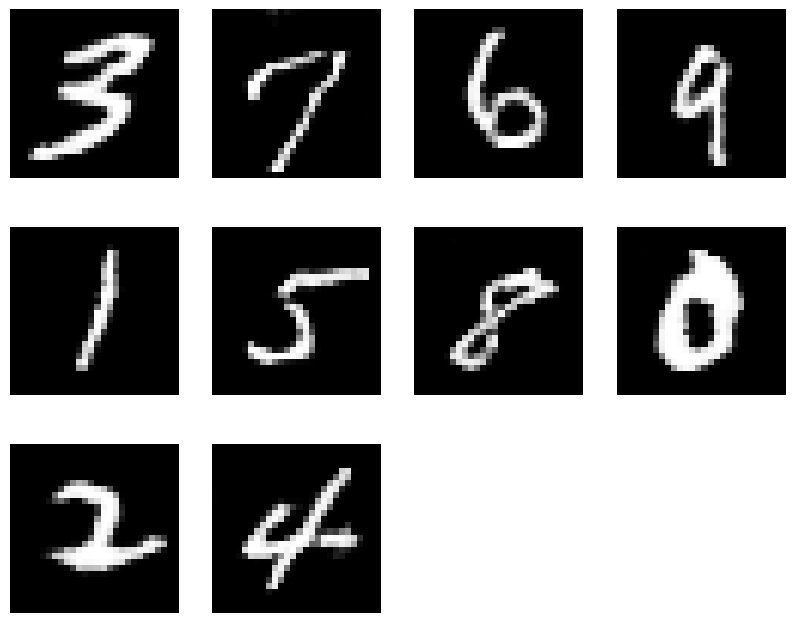

[Epoch 9/50] loss_D: 0.5126, loss_G: 1.2206, loss_info: 0.0491
Generated images:


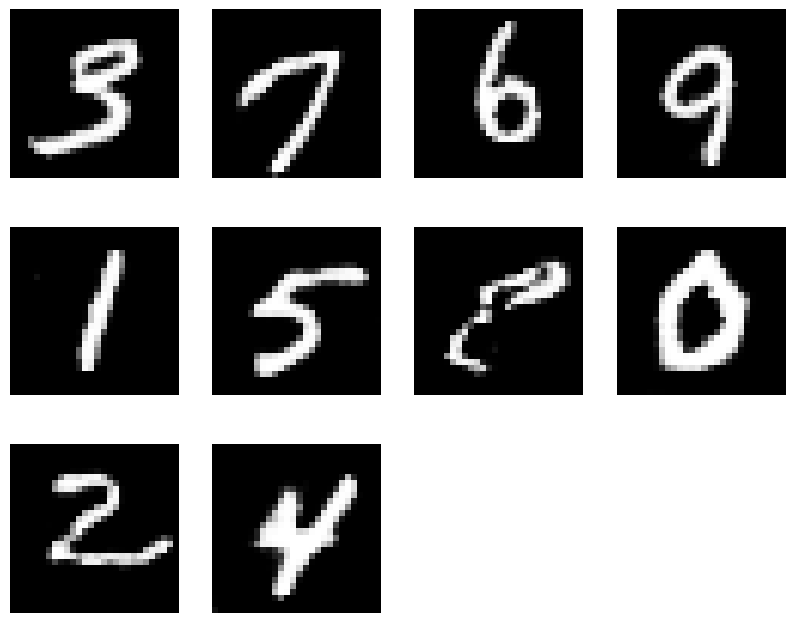

[Epoch 10/50] loss_D: 0.4882, loss_G: 1.2899, loss_info: 0.0461
Generated images:


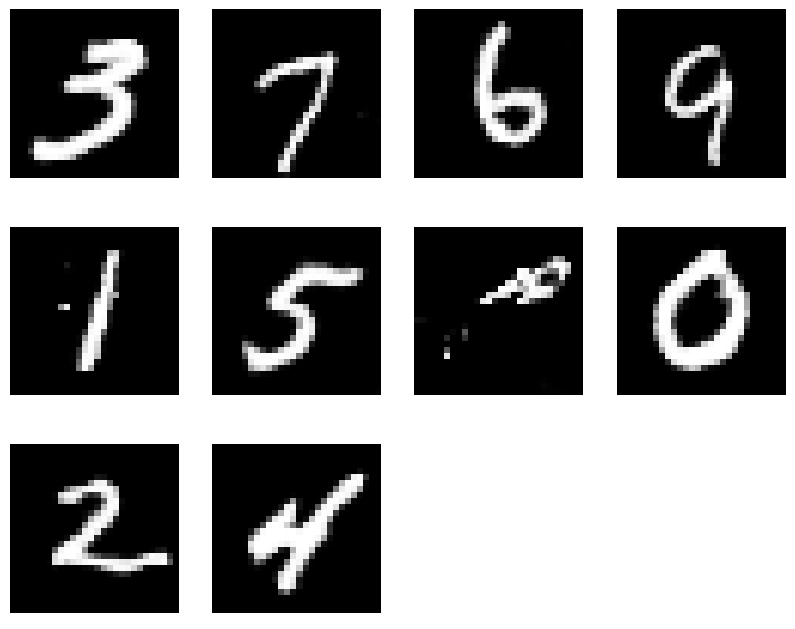

[Epoch 11/50] loss_D: 0.4652, loss_G: 1.3554, loss_info: 0.0460
Generated images:


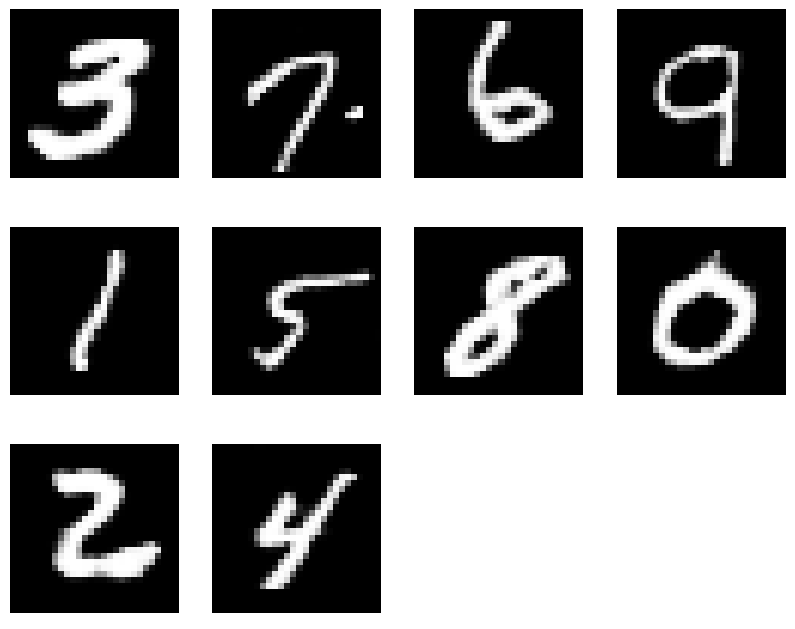

[Epoch 12/50] loss_D: 0.4384, loss_G: 1.4432, loss_info: 0.0478
Generated images:


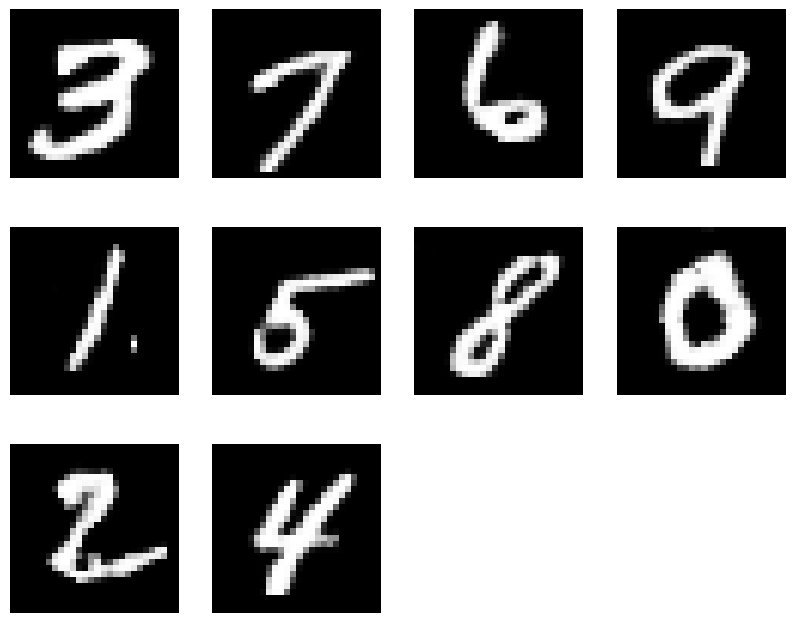

[Epoch 13/50] loss_D: 0.4135, loss_G: 1.5274, loss_info: 0.0487
Generated images:


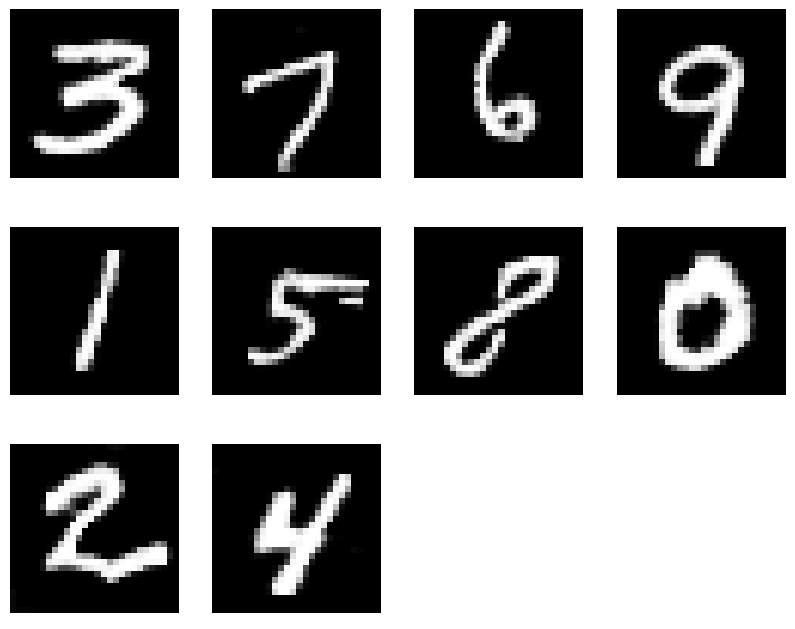

[Epoch 14/50] loss_D: 0.3917, loss_G: 1.6049, loss_info: 0.0502
Generated images:


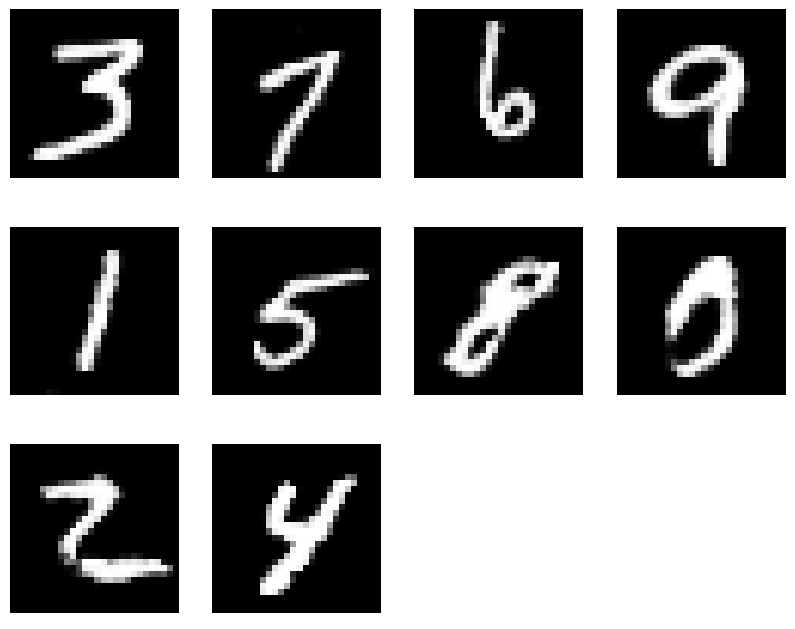

[Epoch 15/50] loss_D: 0.3766, loss_G: 1.6787, loss_info: 0.0516
Generated images:


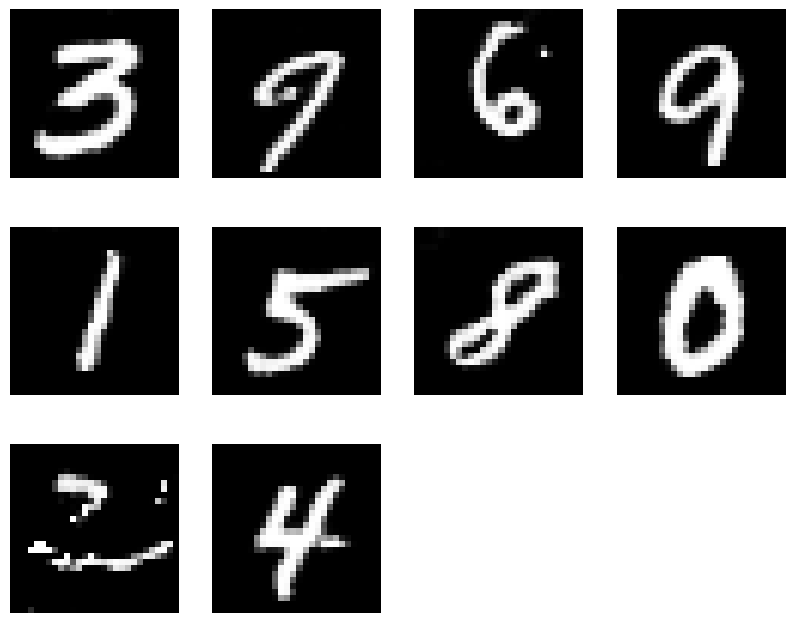

[Epoch 16/50] loss_D: 0.3588, loss_G: 1.7520, loss_info: 0.0497
Generated images:


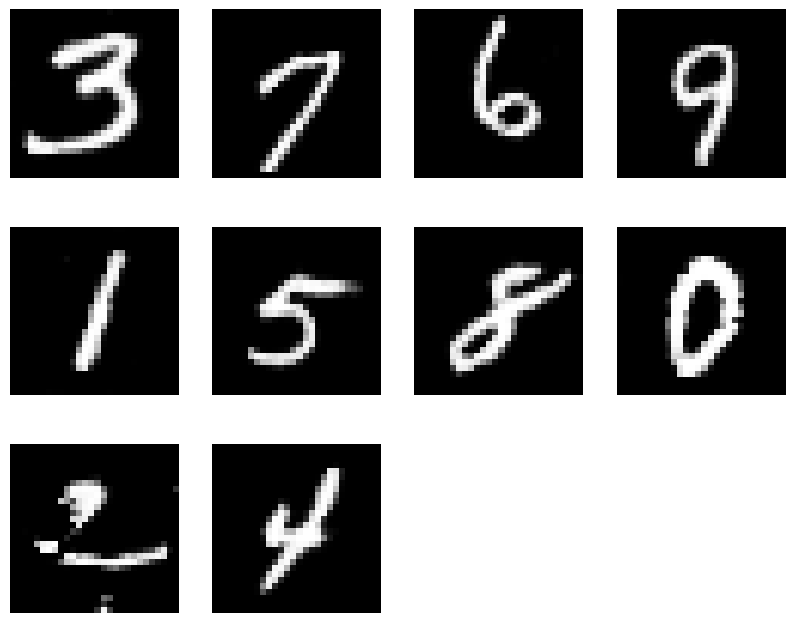

[Epoch 17/50] loss_D: 0.3496, loss_G: 1.8080, loss_info: 0.0499
Generated images:


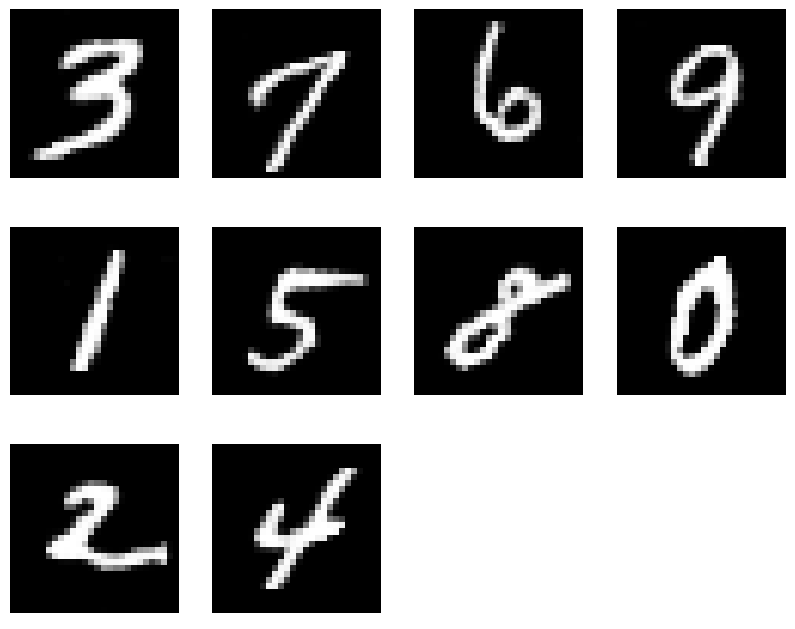

[Epoch 18/50] loss_D: 0.3400, loss_G: 1.8460, loss_info: 0.0526
Generated images:


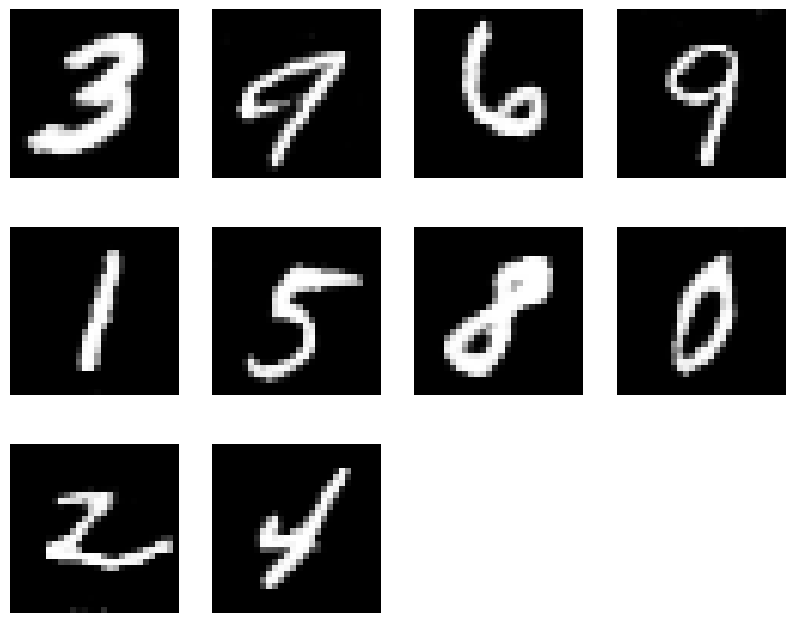

[Epoch 19/50] loss_D: 0.3180, loss_G: 1.9323, loss_info: 0.0547
Generated images:


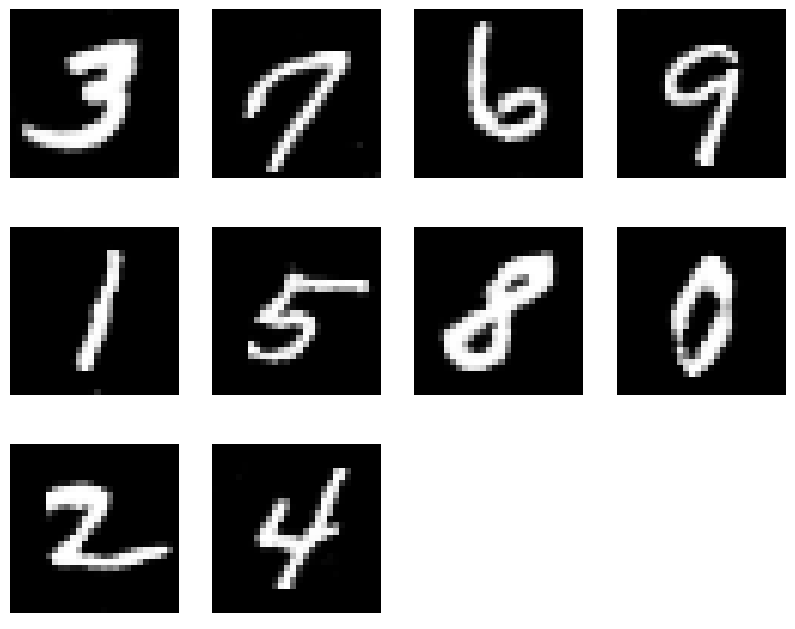

[Epoch 20/50] loss_D: 0.3157, loss_G: 1.9845, loss_info: 0.0527
Generated images:


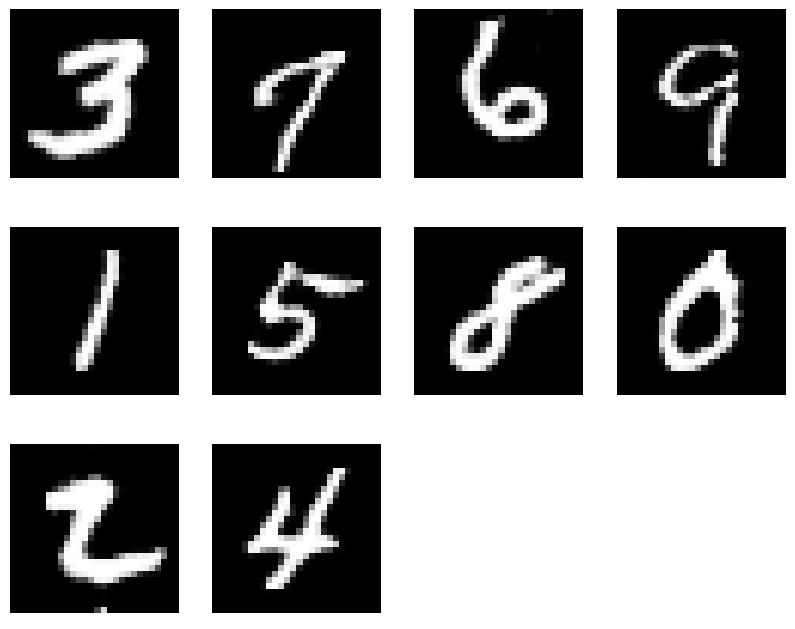

[Epoch 21/50] loss_D: 0.3091, loss_G: 2.0366, loss_info: 0.0527
Generated images:


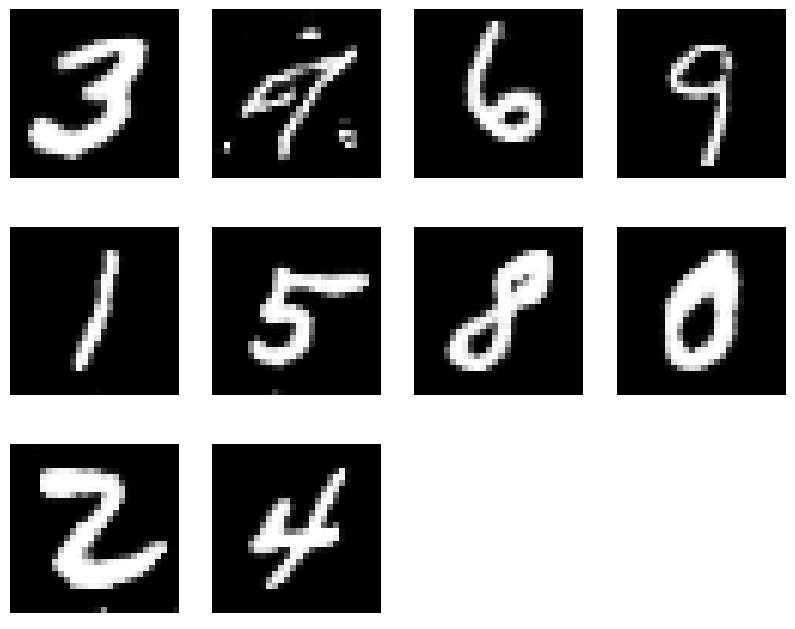

[Epoch 22/50] loss_D: 0.2993, loss_G: 2.0912, loss_info: 0.0536
Generated images:


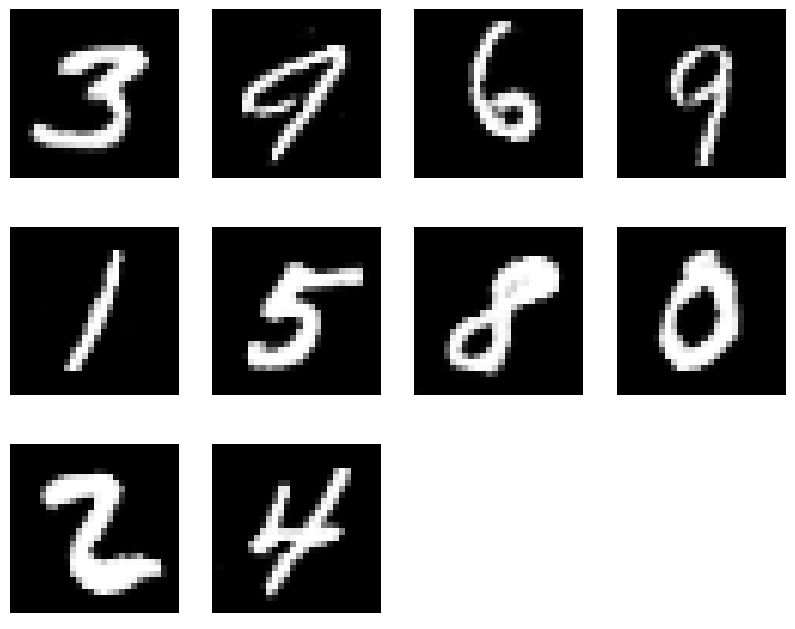

[Epoch 23/50] loss_D: 0.2856, loss_G: 2.1632, loss_info: 0.0541
Generated images:


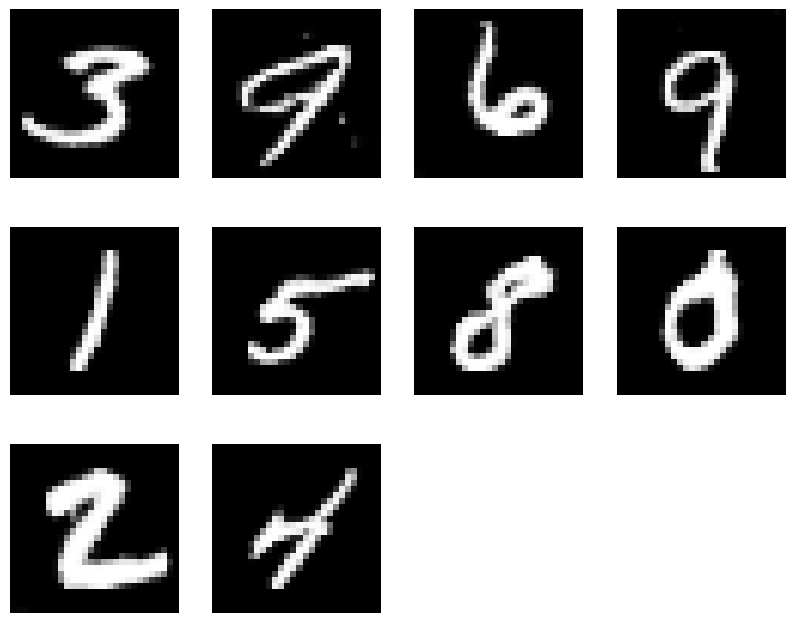

[Epoch 24/50] loss_D: 0.2783, loss_G: 2.2052, loss_info: 0.0544
Generated images:


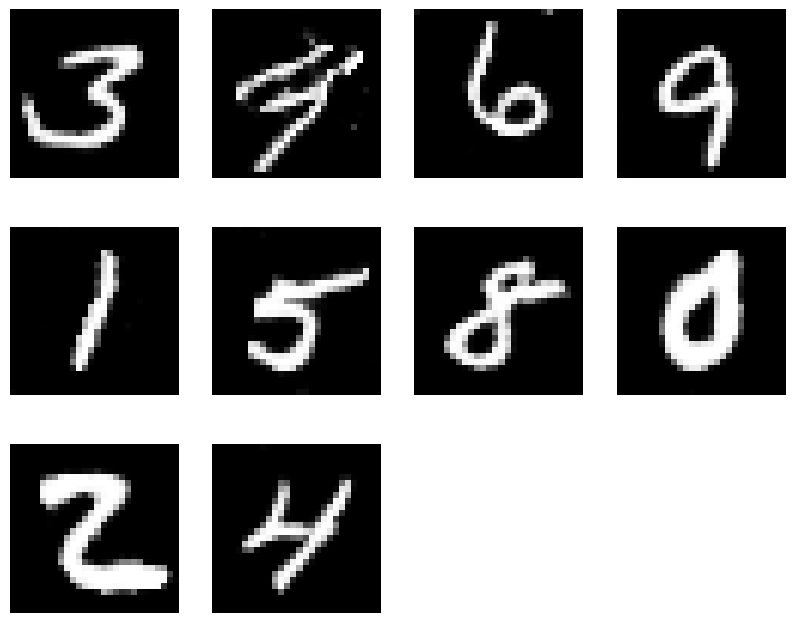

[Epoch 25/50] loss_D: 0.2734, loss_G: 2.2540, loss_info: 0.0564
Generated images:


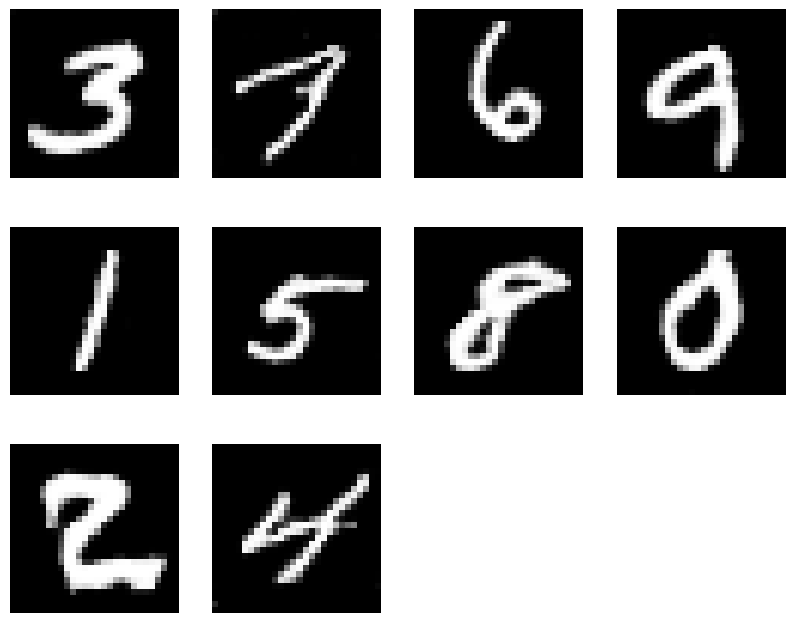

[Epoch 26/50] loss_D: 0.2642, loss_G: 2.3103, loss_info: 0.0552
Generated images:


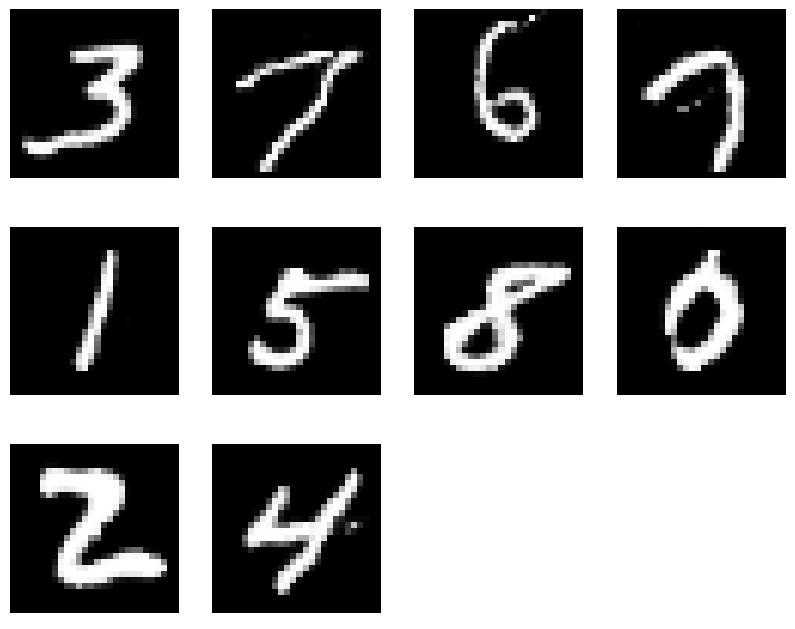

[Epoch 27/50] loss_D: 0.2615, loss_G: 2.3492, loss_info: 0.0520
Generated images:


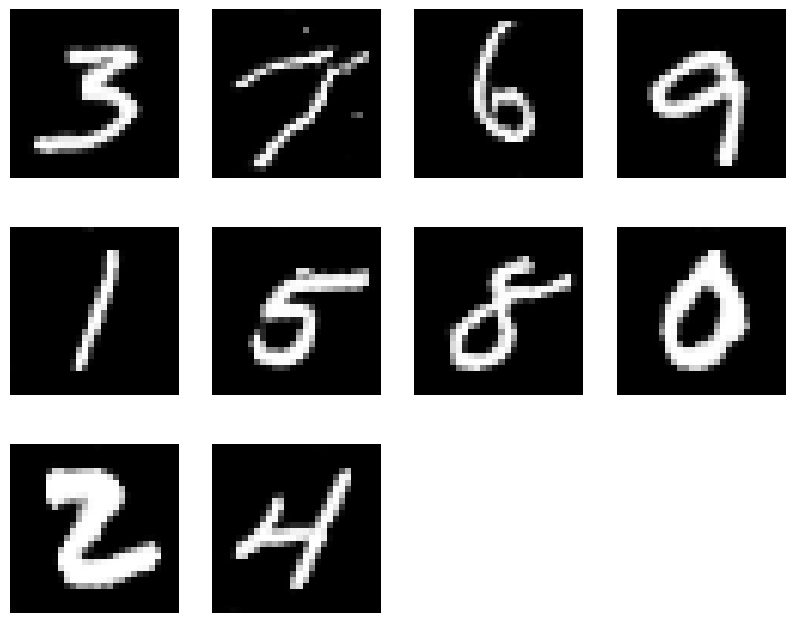

[Epoch 28/50] loss_D: 0.2612, loss_G: 2.3787, loss_info: 0.0548
Generated images:


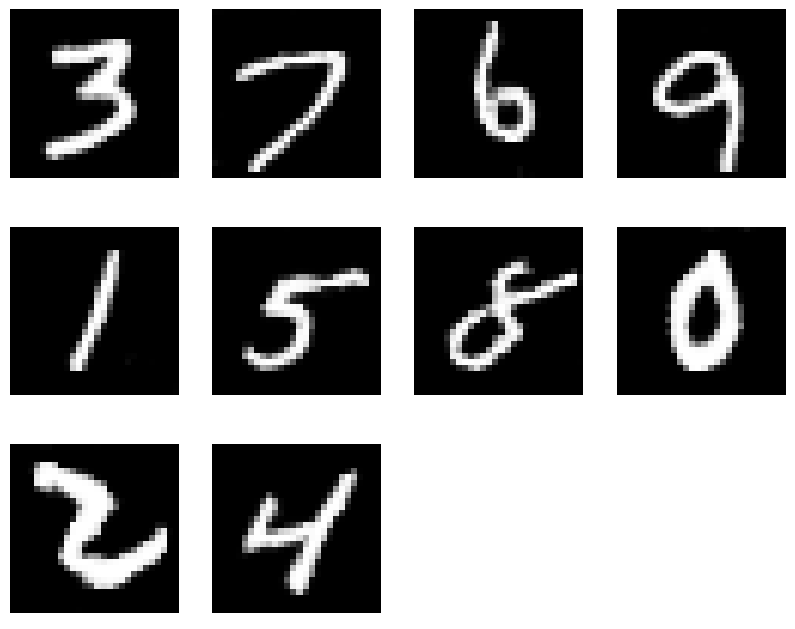

[Epoch 29/50] loss_D: 0.2496, loss_G: 2.4250, loss_info: 0.0550
Generated images:


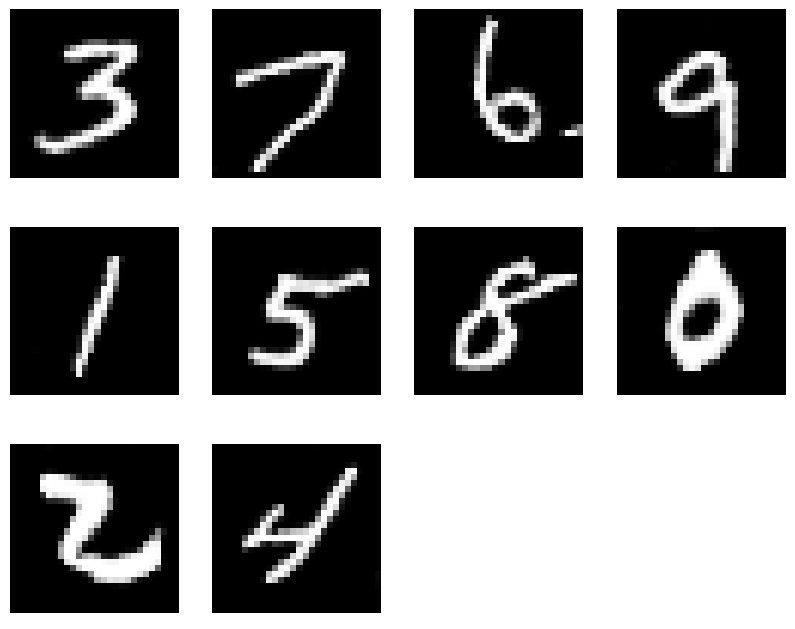

[Epoch 30/50] loss_D: 0.2487, loss_G: 2.4495, loss_info: 0.0580
Generated images:


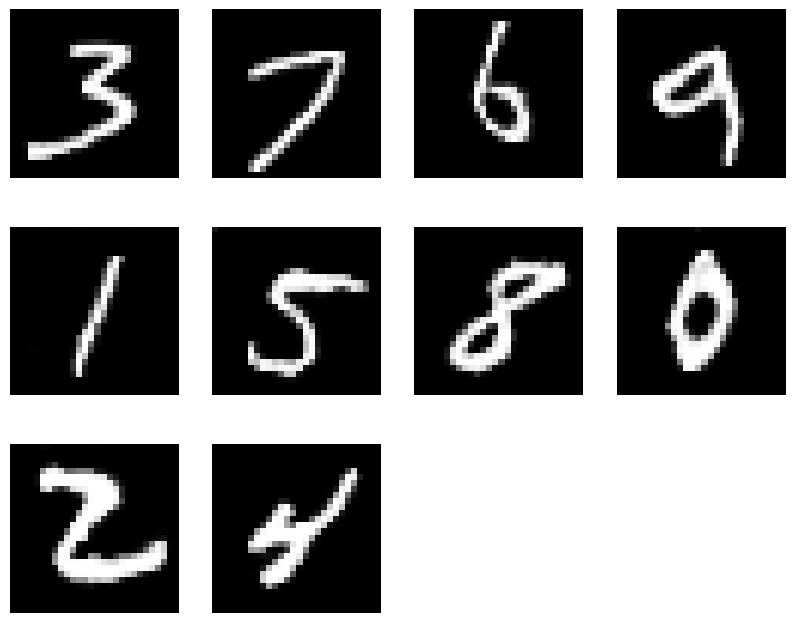

[Epoch 31/50] loss_D: 0.2633, loss_G: 2.4470, loss_info: 0.0553
Generated images:


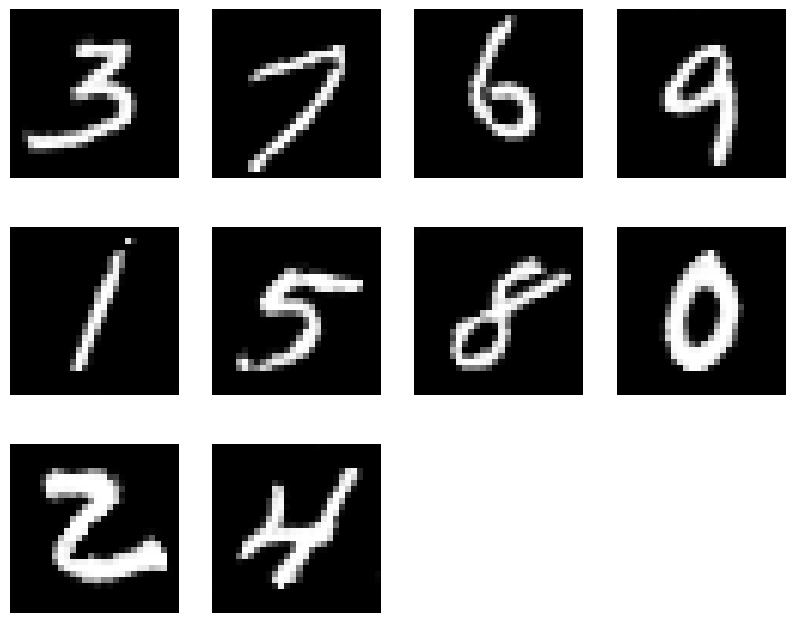

[Epoch 32/50] loss_D: 0.2490, loss_G: 2.4832, loss_info: 0.0529
Generated images:


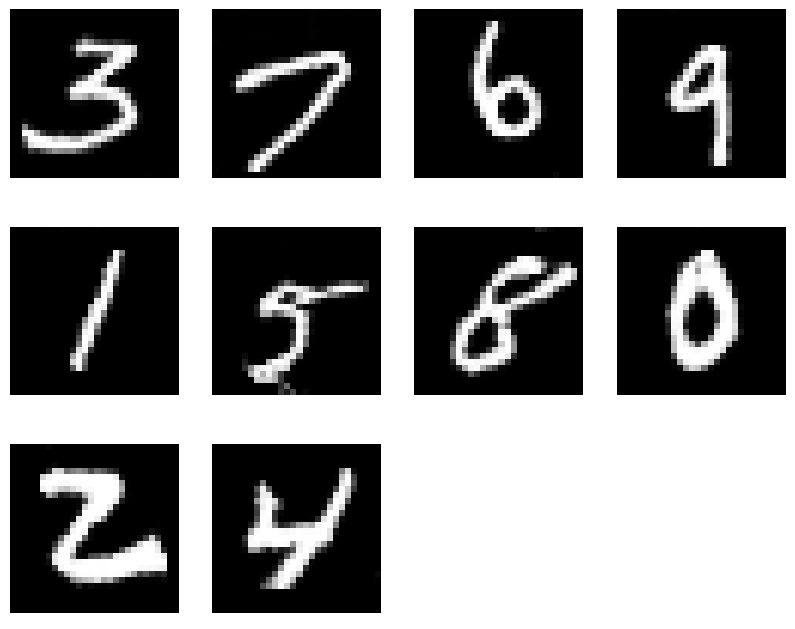

[Epoch 33/50] loss_D: 0.2434, loss_G: 2.5164, loss_info: 0.0552
Generated images:


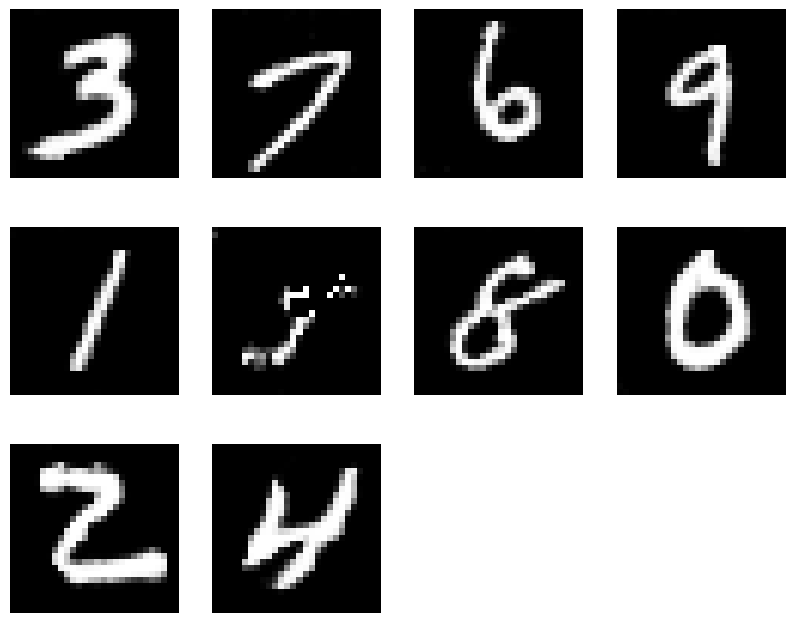

[Epoch 34/50] loss_D: 0.2425, loss_G: 2.5538, loss_info: 0.0542
Generated images:


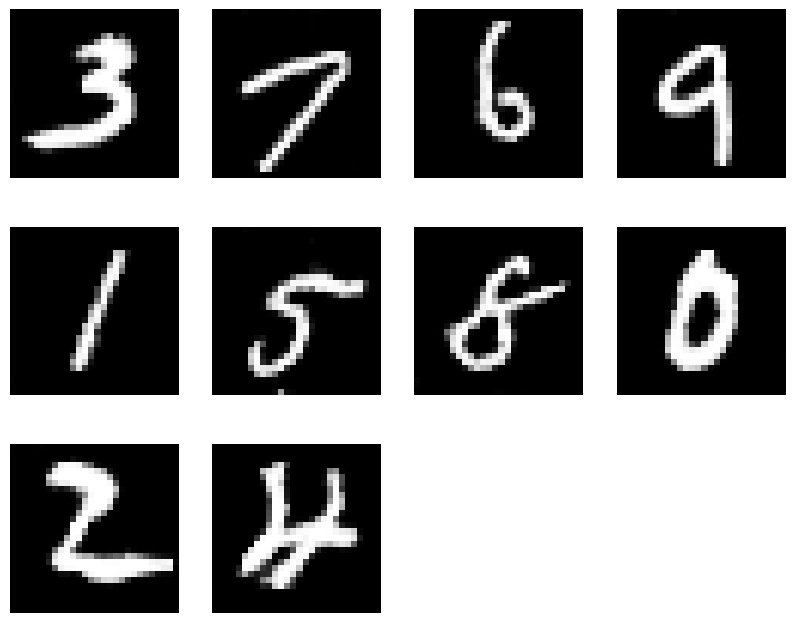

[Epoch 35/50] loss_D: 0.2390, loss_G: 2.5938, loss_info: 0.0561
Generated images:


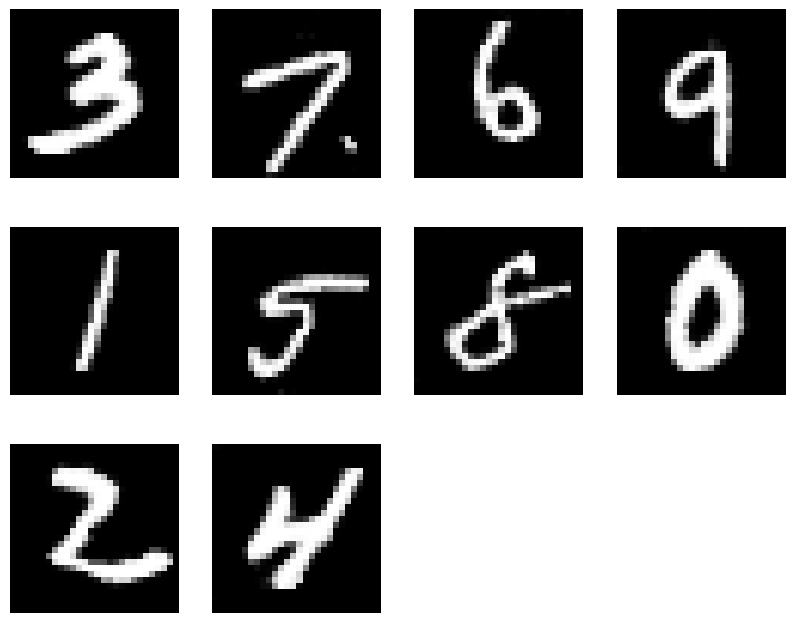

[Epoch 36/50] loss_D: 0.2374, loss_G: 2.6344, loss_info: 0.0588
Generated images:


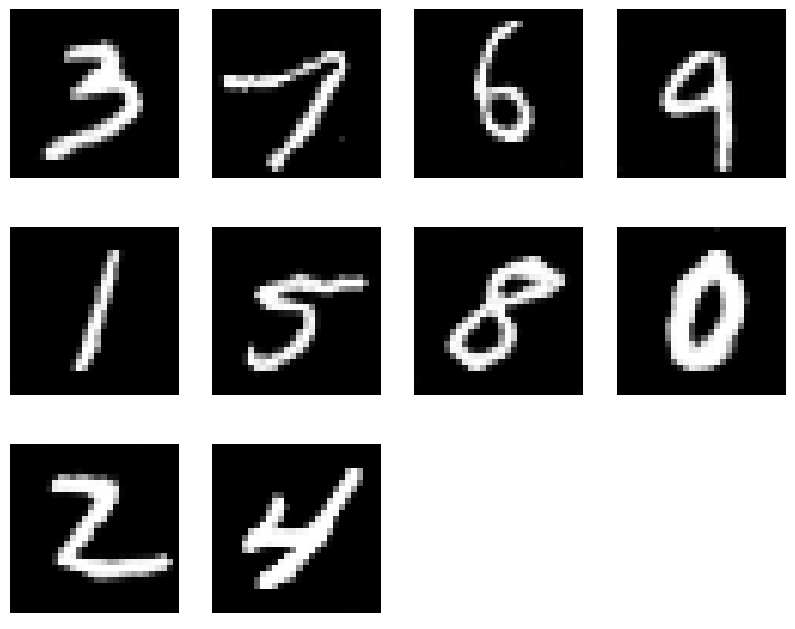

[Epoch 37/50] loss_D: 0.2268, loss_G: 2.6687, loss_info: 0.0588
Generated images:


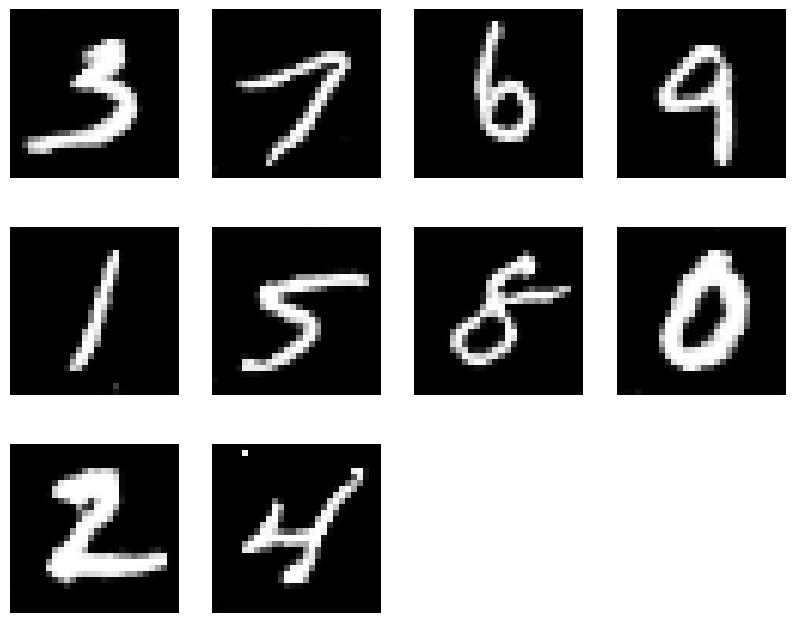

[Epoch 38/50] loss_D: 0.2304, loss_G: 2.6960, loss_info: 0.0580
Generated images:


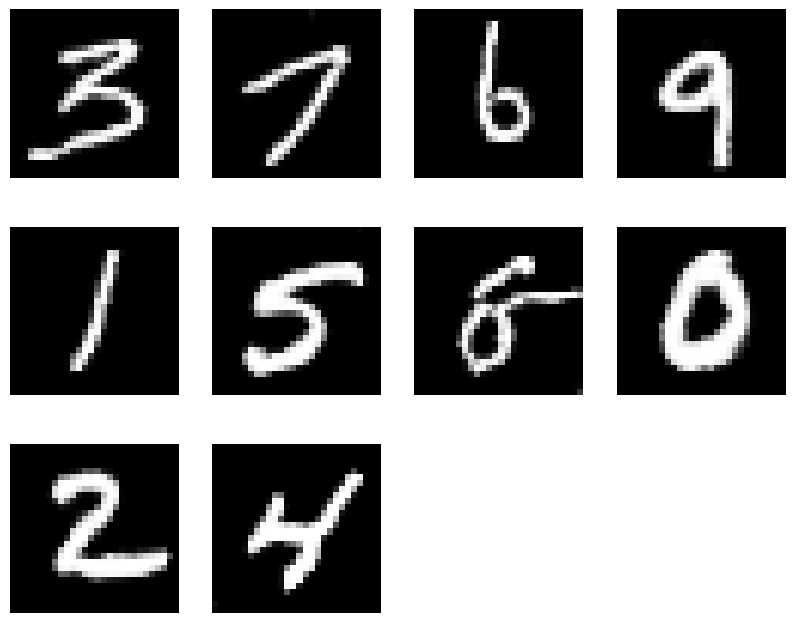

[Epoch 39/50] loss_D: 0.2261, loss_G: 2.7089, loss_info: 0.0587
Generated images:


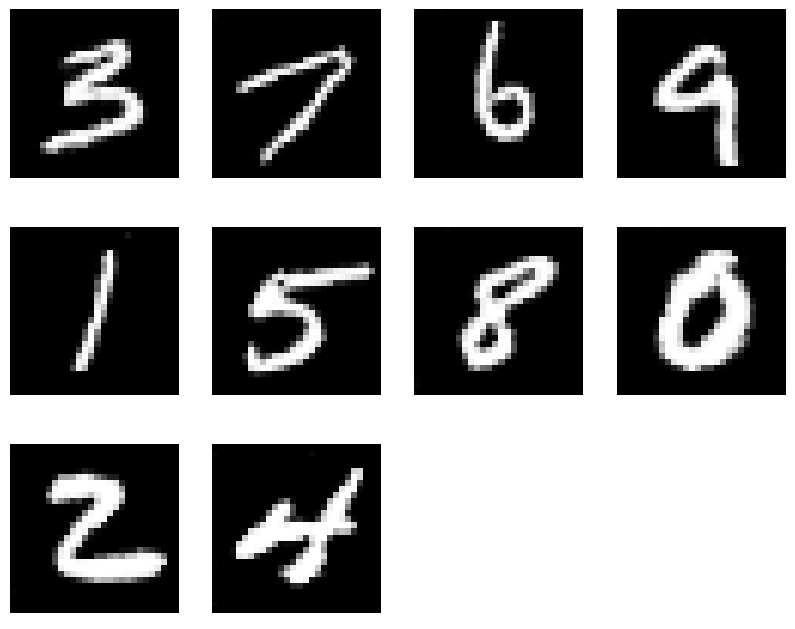

[Epoch 40/50] loss_D: 0.2220, loss_G: 2.7572, loss_info: 0.0582
Generated images:


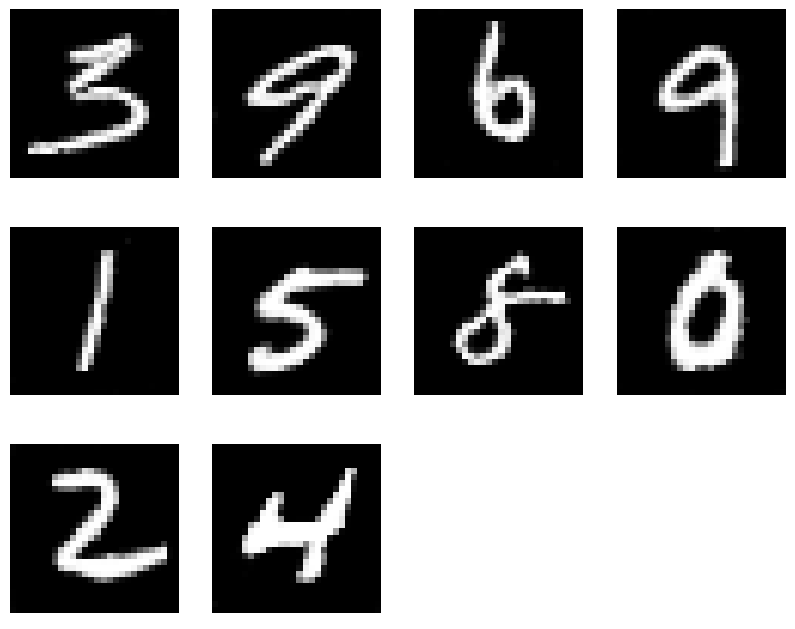

[Epoch 41/50] loss_D: 0.2174, loss_G: 2.8051, loss_info: 0.0569
Generated images:


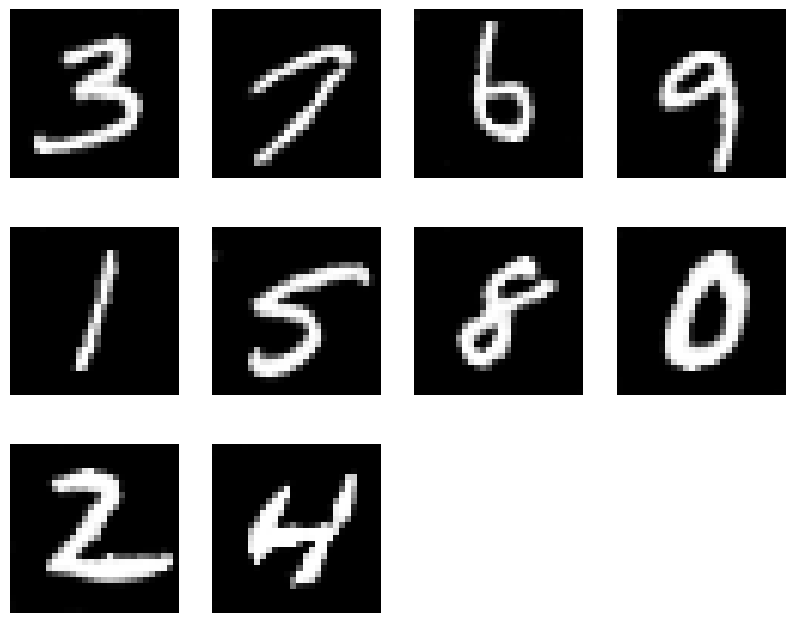

[Epoch 42/50] loss_D: 0.2130, loss_G: 2.8365, loss_info: 0.0571
Generated images:


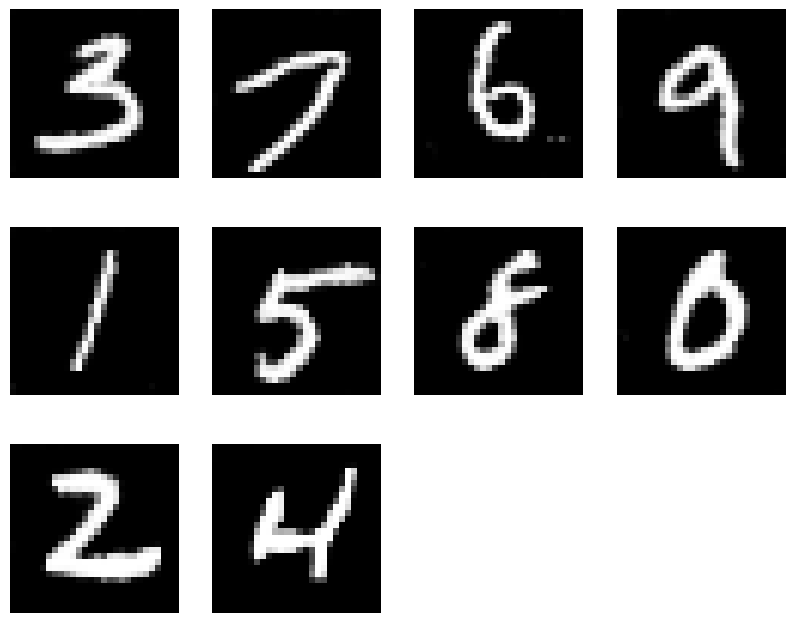

[Epoch 43/50] loss_D: 0.2273, loss_G: 2.8237, loss_info: 0.0549
Generated images:


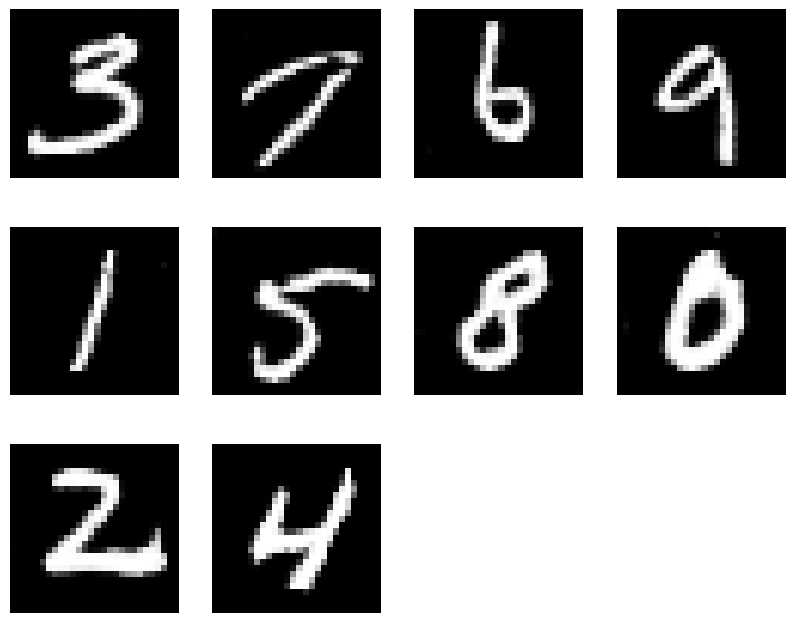

[Epoch 44/50] loss_D: 0.2084, loss_G: 2.8575, loss_info: 0.0541
Generated images:


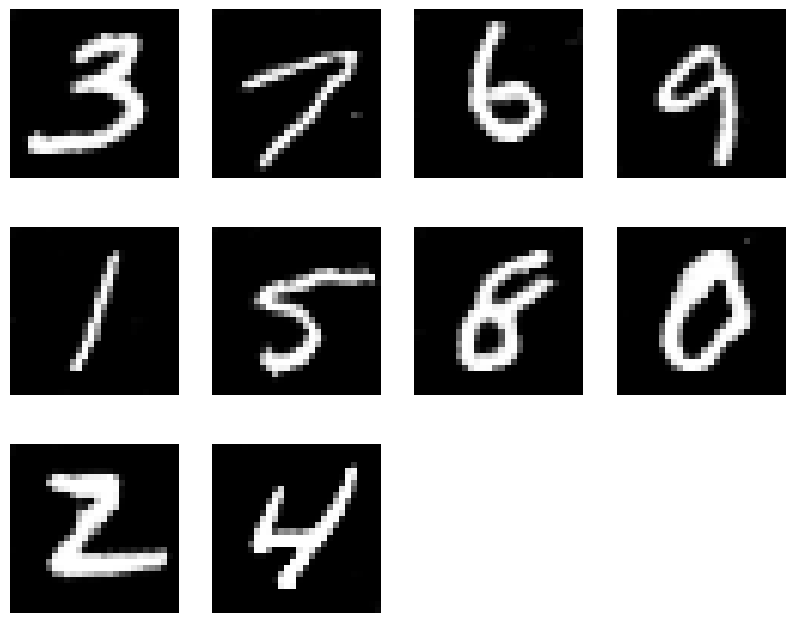

[Epoch 45/50] loss_D: 0.1986, loss_G: 2.9187, loss_info: 0.0567
Generated images:


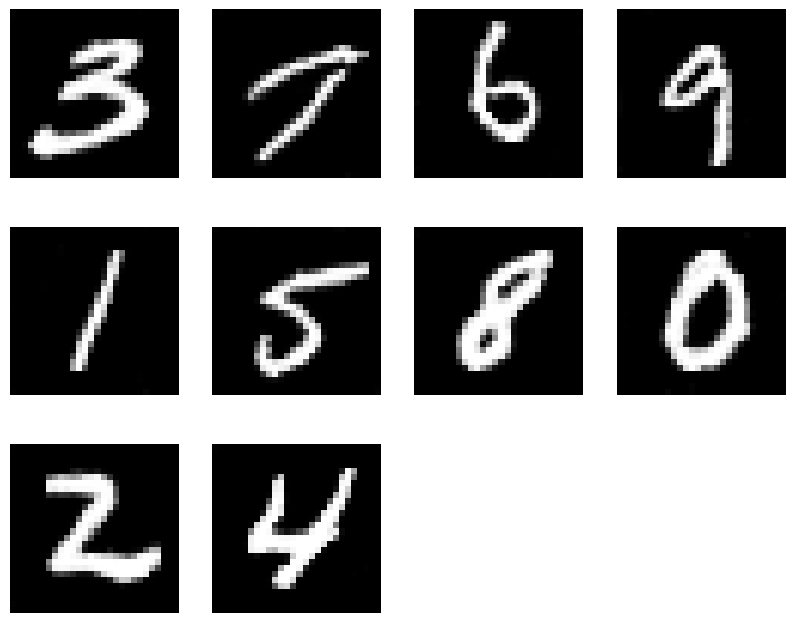

[Epoch 46/50] loss_D: 0.2018, loss_G: 2.9346, loss_info: 0.0557
Generated images:


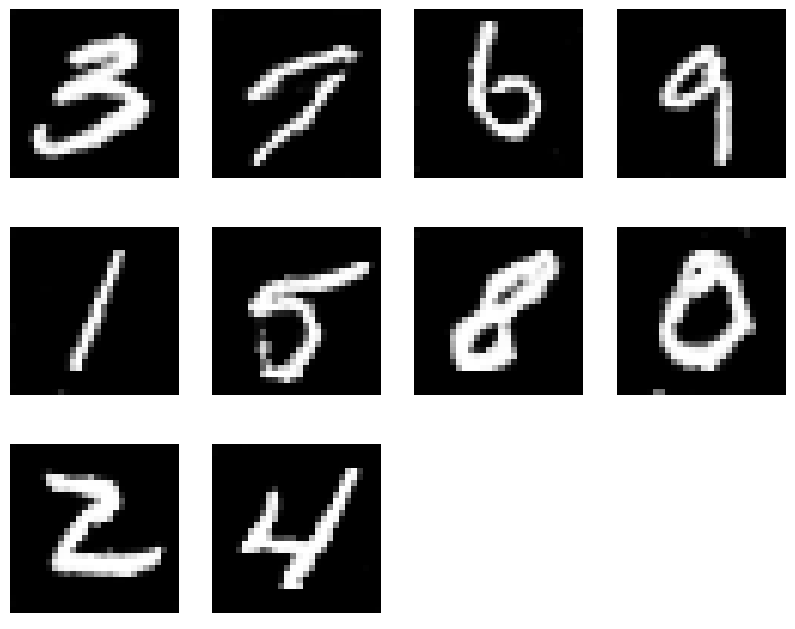

[Epoch 47/50] loss_D: 0.2100, loss_G: 2.9568, loss_info: 0.0576
Generated images:


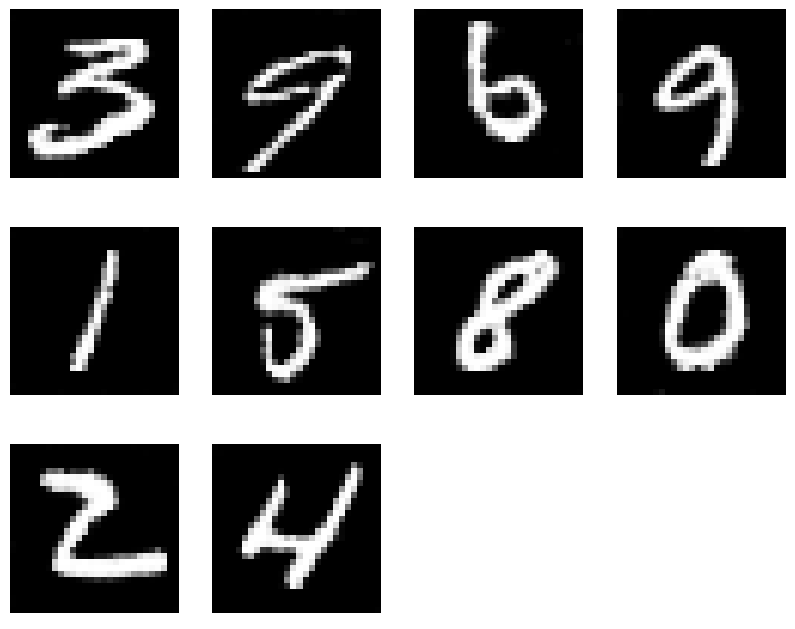

[Epoch 48/50] loss_D: 0.2029, loss_G: 2.9842, loss_info: 0.0582
Generated images:


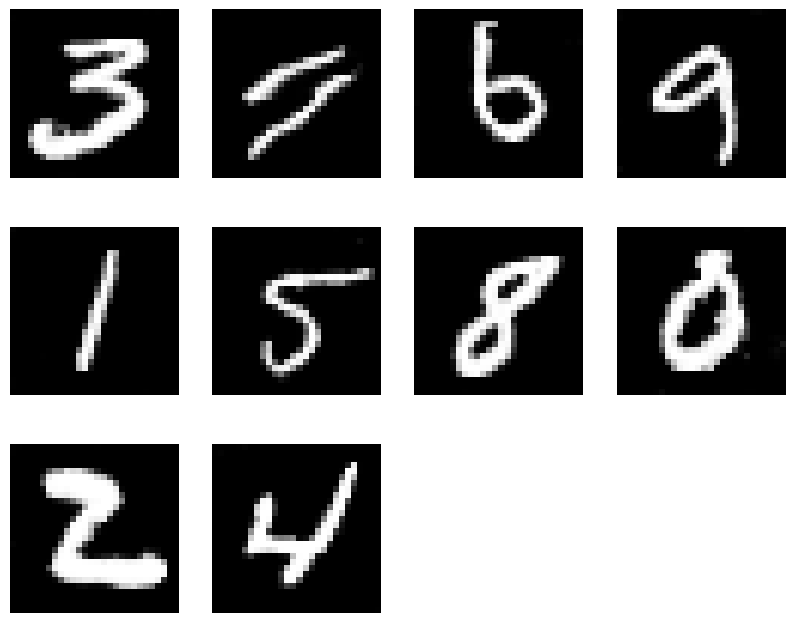

[Epoch 49/50] loss_D: 0.1988, loss_G: 3.0096, loss_info: 0.0587
Generated images:


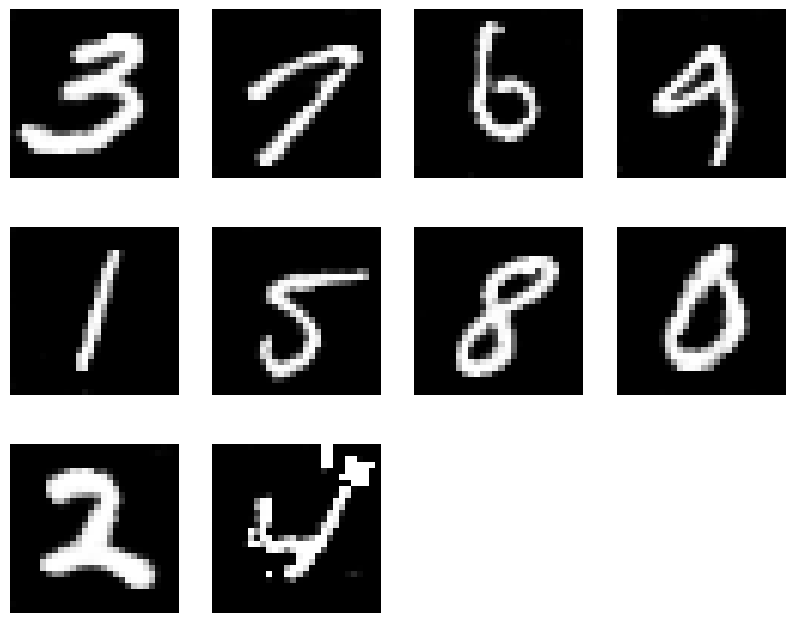

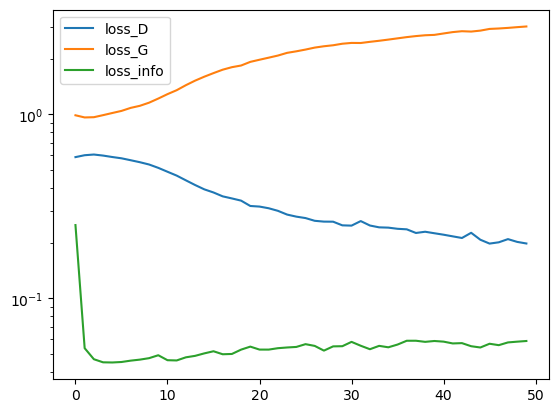

In [14]:
lr_D = 2.e-4
lr_G = 1e-3
lambd = 1.

num_epochs = 50
device = torch.device("cuda") if torch.cuda.is_available() else torch.device("cpu")

latent_dim = 62
num_codes = 2
num_classes = 10
discriminator = Discriminator(init_channels=64, num_classes=num_classes, num_codes=num_codes).to(device)
generator = Generator(init_channels=1024, latent_dim=latent_dim, num_classes=num_classes, num_codes=num_codes).to(device)
    
fixed_noise = torch.normal(0., 1., size=(10, latent_dim))
fixed_label = F.one_hot(torch.arange(10)).float()
fixed_code = 2. * torch.rand(10, num_codes) - 1.
train_infogan(
    D=discriminator, G=generator, lr_D=lr_D, lr_G=lr_G, lambd=lambd,
    latent_dim=latent_dim, num_codes=num_codes,dataloader=train_dataloader, num_epochs=num_epochs, 
    device=device, fixed_noise=fixed_noise, fixed_label=fixed_label, fixed_code=fixed_code, 
    visualize=True)

In [15]:
num_examples = 12
labels = F.one_hot(torch.arange(10)).float().repeat_interleave(num_examples,dim=0).to(device)
noise = torch.normal(0., 1., size=(num_examples, latent_dim)).to(device)
code_vary_c2 = torch.cat(
    (2. * torch.rand(num_examples, 1) - 1., torch.linspace(-2,2,num_examples).reshape(-1,1)),
    dim=1).to(device)
code_vary_c3 = torch.cat(
    (torch.linspace(-2,2,num_examples).reshape(-1,1), 2. * torch.rand(num_examples, 1) - 1.),
    dim=1).to(device)

In [16]:
def vary_ci(ci):
    if ci=="c2":
        code = code_vary_c2
    elif ci=="c3":
        code = code_vary_c3
    else: return

    generator.eval()

    gen_imgs = []

    for i in range(10):
        with torch.no_grad():
            fake_data = generator(noise, labels[i*num_examples:(i+1)*num_examples], code).detach().cpu()
            gen_imgs.append(fake_data)
    gen_imgs = torch.cat(gen_imgs, dim=0)
    fig, ax = plt.subplots(figsize=(19.2,10.8))
    ax.imshow(T.ToPILImage()(make_grid(gen_imgs, nrow=num_examples)))
    ax.axis("off")
    plt.savefig(f"vary_{ci}.png")
    plt.show()

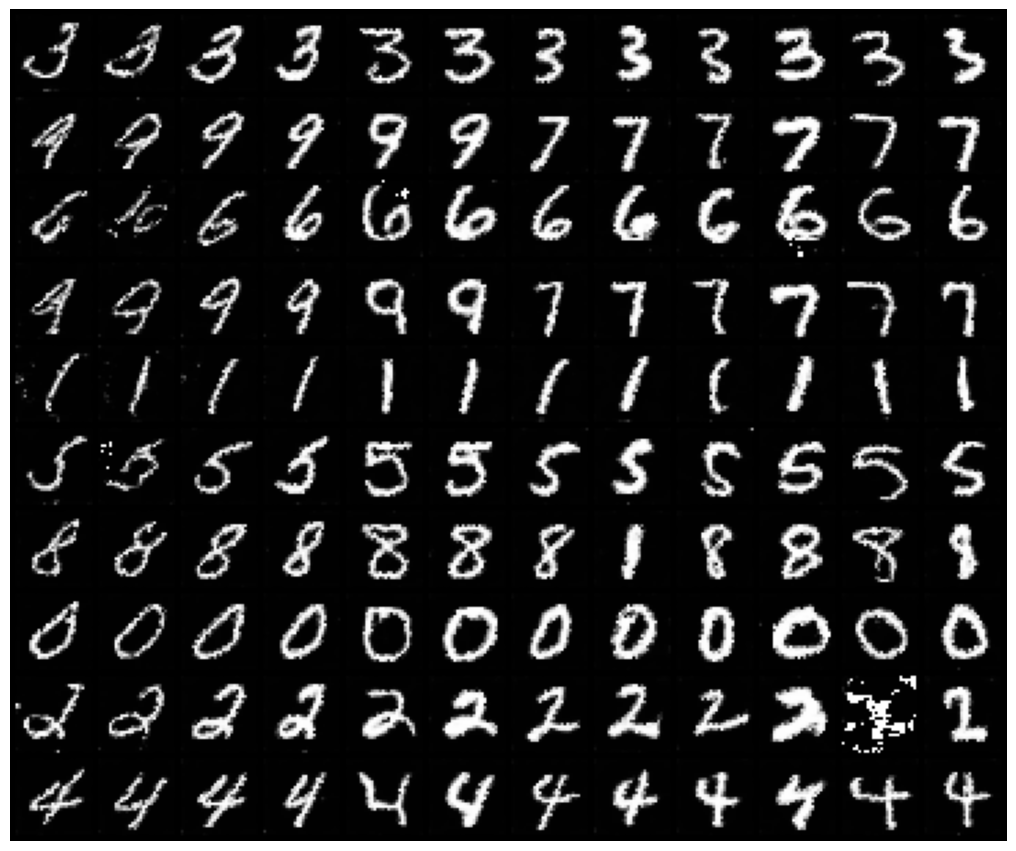

In [17]:
vary_ci("c2")

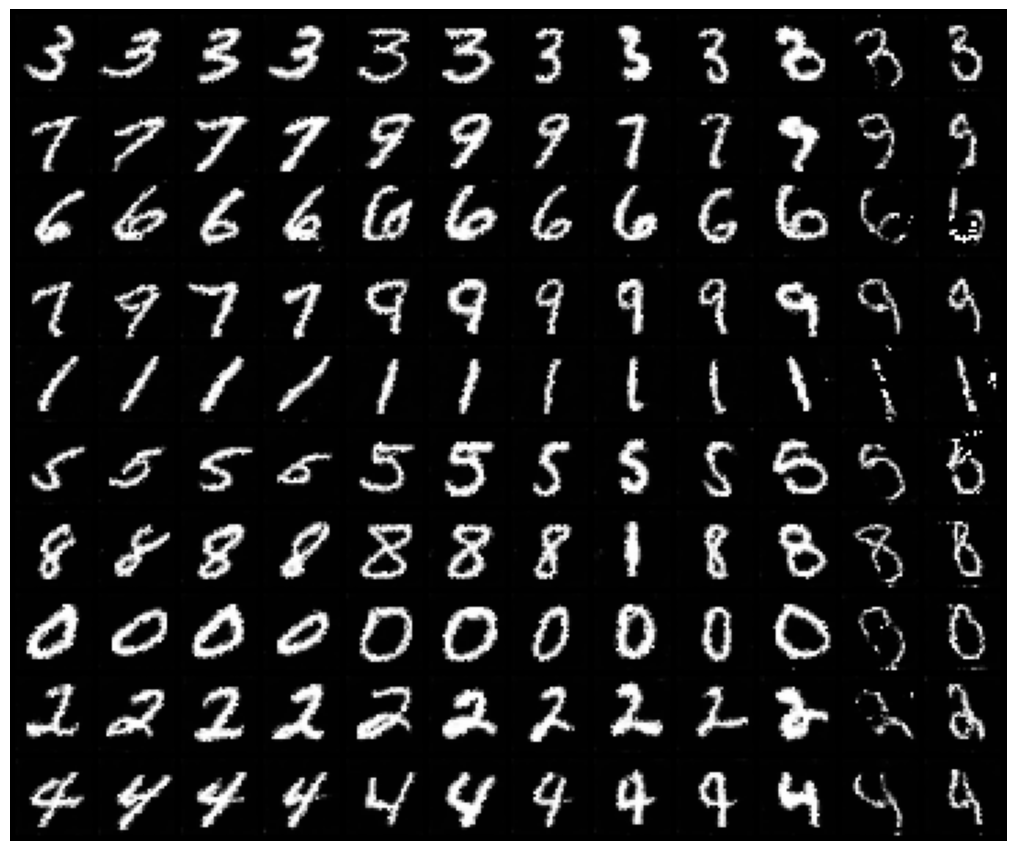

In [18]:
vary_ci("c3")